In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import random
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from scipy import stats
# from matplotlib_venn import venn2
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from numba import jit
from matplotlib.colors import Normalize
import cmapPy
import cmapPy.pandasGEXpress.parse as parse
import gzip
from scipy.optimize import minimize



443 443


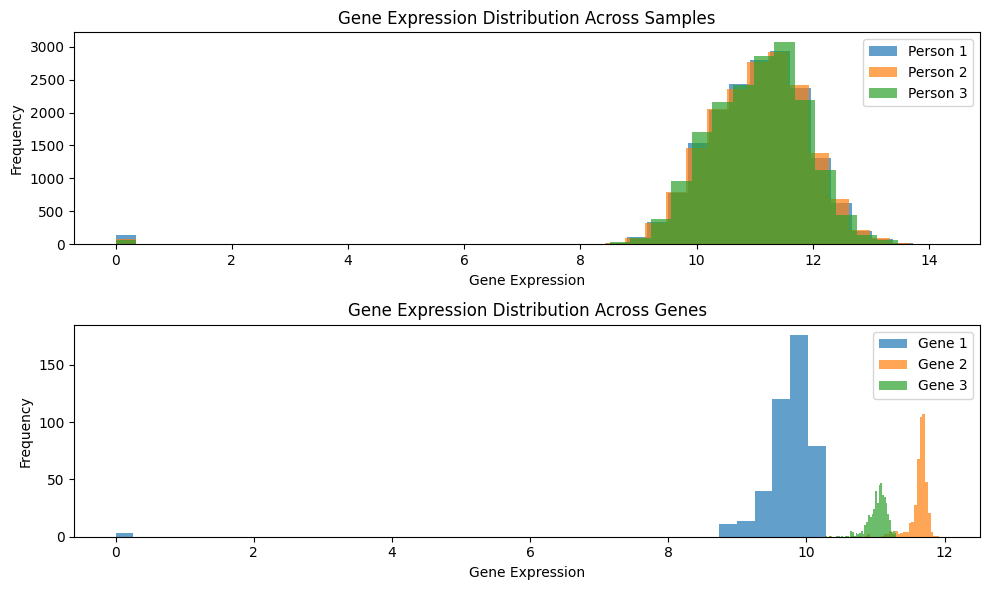

In [2]:


X = np.load('expression_GSE96783_series_matrix.npy')
X = np.transpose(X)

y = np.load('traits_asthma_GSE96783_series_matrix.npy')

print(len(y), len(X))

import matplotlib.pyplot as plt

# Plot histograms for the first three genes across samples
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.hist(X[0, :], bins=40, alpha=0.7, label='Person 1')
plt.hist(X[1, :], bins=40, alpha=0.7, label='Person 2')
plt.hist(X[2, :], bins=40, alpha=0.7, label='Person 3')
plt.xlabel('Gene Expression')
plt.ylabel('Frequency')
plt.title('Gene Expression Distribution Across Samples')
plt.legend()

# Plot histograms for the first three samples across genes
plt.subplot(2, 1, 2)
plt.hist(X[:, 0], bins=40, alpha=0.7, label='Gene 1')
plt.hist(X[:, 1], bins=40, alpha=0.7, label='Gene 2')
plt.hist(X[:, 2], bins=40, alpha=0.7, label='Gene 3')
plt.xlabel('Gene Expression')
plt.ylabel('Frequency')
plt.title('Gene Expression Distribution Across Genes')
plt.legend()

plt.tight_layout()
plt.show()


def plot_reconstructions():
    reconstructed_samples = []


    batch_size = 1  # Adjust batch size as needed
    gene_count = X.shape[1]  # Number of genes in your data
    final_sequence_length = 1  # Since it's a single-dimensional sequence
    num_classes = y.shape[1]  # Number of classes in your labels
    dataset = TensorDataset(X_tensor, y_tensor)
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


    with torch.no_grad():
        for batch_X, batch_y in data_loader:
    #         batch_X = batch_X.view(-1, gene_count, final_sequence_length)  # Reshape the input batch if needed
            _, _, mean, log_var = cvae(batch_X, batch_y)  # Run the CVAE model to get mean and log_var
            z = cvae.reparameterize(mean, log_var)  # Reparameterize to get latent vectors
            reconstructed_batch = cvae.decoder(z)  # Generate reconstructed data
            reconstructed_samples.append(reconstructed_batch.numpy())

    reconstructed_samples = np.concatenate(reconstructed_samples, axis=0)
    Xr = scaler.inverse_transform(reconstructed_samples)

    # Visualize the original data and their reconstructions
    num_samples = min(5, len(data_loader))  # Number of samples to visualize
    sample_indices = np.random.choice(len(data_loader), num_samples, replace=False)


    import matplotlib.pyplot as plt

    plt.figure(figsize=(15, 10))  # Adjust the figure size as needed

    num_genes = 9  # Total number of genes for visualization

    for i in range(num_genes):
        plt.subplot(3, 3, i + 1)  # Create a subplot
        plt.hist(Xr[:, i], bins=40, alpha=0.25, label=f'Reconstructed Gene {i + 1}', color = 'r', density = True)
        plt.hist(X[:, i], bins=40, alpha=0.25, label=f'Original Gene {i + 1}', color = 'b',  density = True)
        plt.xlabel('Gene Expression')
        plt.ylabel('Frequency')
        plt.title(f'Gene {i + 1} Expression: Original vs Reconstructed')
        plt.legend()

    plt.tight_layout()  # Adjust layout for better spacing
    plt.show()
    
    
import numpy as np
from sklearn.decomposition import PCA
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
from sklearn.neighbors import KernelDensity
import matplotlib.pyplot as plt
def sample_from_ball_01(num_samples, l0, l1):

    
    latent_vectors = []
    true_labels = []

    batch_size = 1  # Adjust batch size as needed

    batch_size = 1  # Adjust batch size as needed
    gene_count = X.shape[1]  # Number of genes in your data
    final_sequence_length = 1  # Since it's a single-dimensional sequence
    num_classes = y.shape[1]  # Number of classes in your labels
    # dataset = TensorDataset(X_tensor, y_tensor)
    dataset = TensorDataset(X_tensor, y_tensor)
    data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            _, _, mean, log_var = cvae(batch_X, batch_y)  # Run the CVAE model to get mean and log_var
            z = cvae.reparameterize(mean, log_var)  # Reparameterize to get latent vectors
            latent_vectors.append(mean.numpy())
            true_labels.append(batch_y.argmax(dim=1).numpy())


    

    latent_vectors = np.concatenate(latent_vectors, axis=0)
    true_labels = np.concatenate(true_labels, axis=0)
    
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(latent_vectors)
    plt.figure(figsize=(12, 6))
    plt.scatter(pca_result[:, 0], pca_result[:, 1], c = true_labels, cmap='jet', alpha=0.25)
    plt.colorbar()
    plt.title('PCA Visualization with Interpolation Path')
    plt.show()
    
    z0, z1 = latent_vectors[true_labels == l0], latent_vectors[true_labels == l1]
    

    # Assuming you have cluster points z0 and z1 as numpy arrays
    # You can choose the bandwidth parameter (adjust as needed)
    bandwidth = 0.2

    # Create a KernelDensity estimator for cluster z0
    kde_z0 = KernelDensity(bandwidth=bandwidth)
    kde_z0.fit(z0)

    # Create a KernelDensity estimator for cluster z1
    kde_z1 = KernelDensity(bandwidth=bandwidth)
    kde_z1.fit(z1)

    # Number of samples to draw from each cluster
    n_samples = 100

    # Draw n_samples from cluster z0
    samples_z0 = kde_z0.sample(num_samples)
    samples_z0 = np.array(samples_z0)

    # Draw n_samples from cluster z1
    samples_z1 = kde_z1.sample(num_samples)
    samples_z1 = np.array(samples_z1)
    samples_points = np.concatenate((samples_z0, samples_z1))
    
    pca = PCA(n_components=2)
    z_2d =  pca.fit_transform(samples_points)
    plt.figure(figsize=(12, 6))
    # Visualize the sampled points (adjust as needed)
    true_labels = np.concatenate((np.ones(num_samples),np.zeros(num_samples)))
    plt.scatter(z_2d[:, 0], z_2d[:, 1], c = true_labels, cmap='jet', alpha=0.25)
    plt.colorbar()
    plt.title('PCA from Cluster sampling')
    plt.xlabel('Latent Space Dimension 1')
    plt.ylabel('Latent Space Dimension 2')
    plt.show()




    samples_z0 = torch.tensor(samples_z0, dtype=torch.float32)
    samples_z1 = torch.tensor(samples_z1, dtype=torch.float32)
    
    # Sample points around label0 centroid
    X0_reconstructed, X1_reconstructed = [],[]
    for i in range(num_samples):
        X0_reconstructed.append(cvae.decoder(samples_z0[i]).detach().numpy())
        X1_reconstructed.append(cvae.decoder(samples_z1[i]).detach().numpy())

        
    sampled_points_label0, sampled_points_label1 = np.asarray(samples_z0), np.asarray(samples_z1)
    true_labels = np.concatenate((np.zeros(num_samples),np.ones(num_samples)))
    X0_reconstructed, X1_reconstructed = np.asarray(X0_reconstructed), np.asarray(X1_reconstructed)
    samples_points = np.concatenate((sampled_points_label0, sampled_points_label1))

    
    return X0_reconstructed, X1_reconstructed


Data Min: [ 0.         10.32654055 10.27520566 ...  0.          8.82232595
  0.        ]
Data Max: [10.27560801 11.91567349 11.29999107 ... 12.37464506 10.24941015
  9.8758835 ]
X_train shape: (354, 17726)
X_test shape: (89, 17726)
y_train shape: (354, 2)
y_test shape: (89, 2)


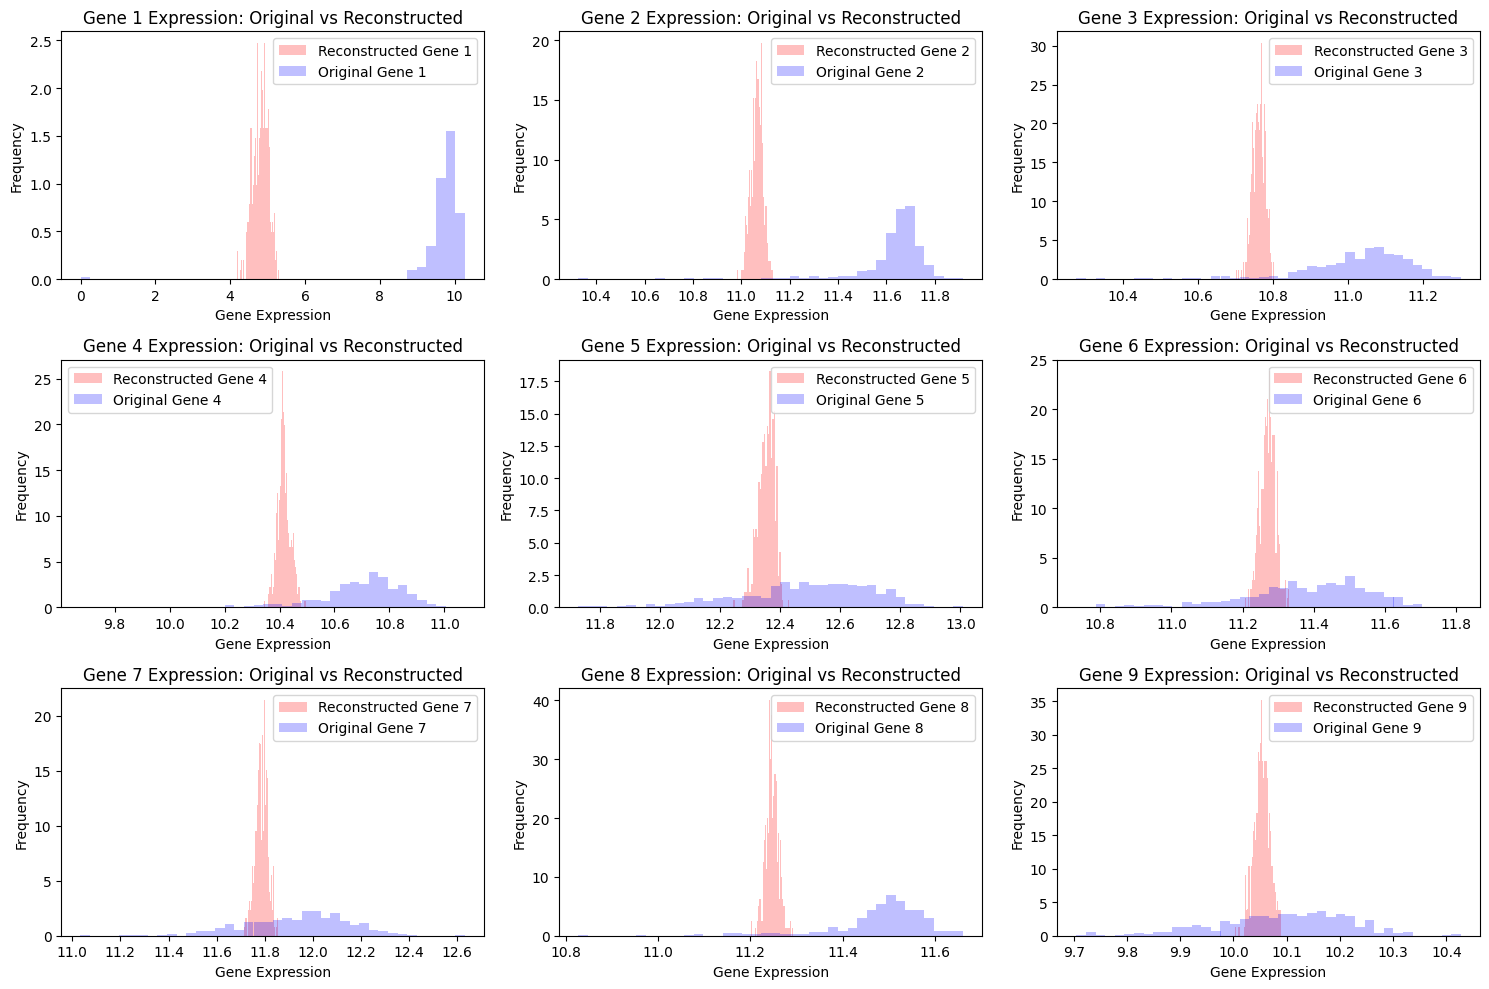

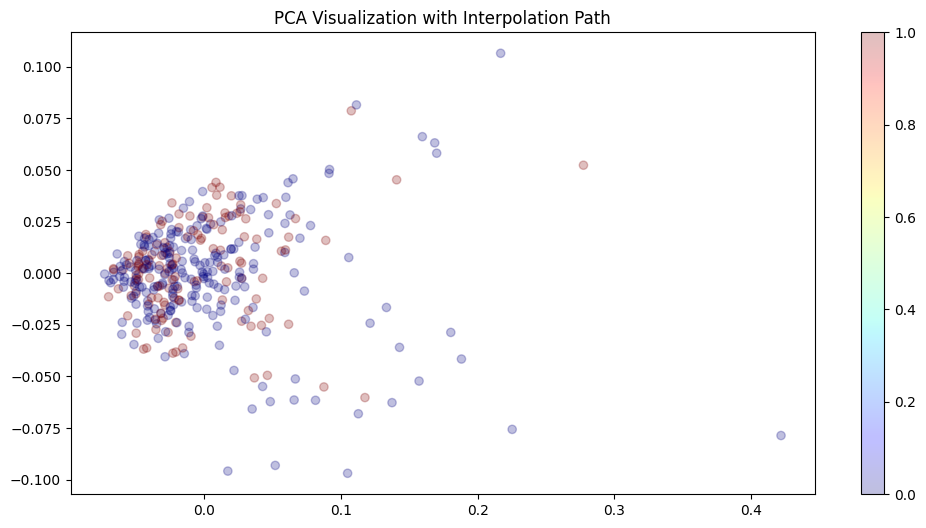

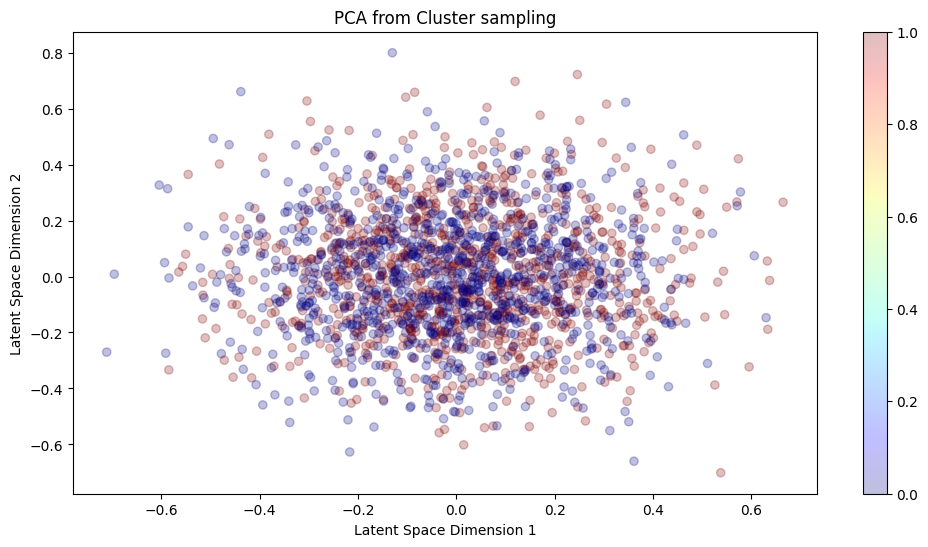

Epoch [1/1000], Recon : 0.0842, KL : 1.2597, Ortho : 62.4255, Class: 0.7209, Accuracy: 56.21%
Epoch [2/1000], Recon : 0.0828, KL : 2.3778, Ortho : 119.6269, Class: 0.6485, Accuracy: 62.43%
Epoch [3/1000], Recon : 0.0787, KL : 4.4621, Ortho : 228.3561, Class: 0.6637, Accuracy: 61.58%
Epoch [4/1000], Recon : 0.0707, KL : 15.3978, Ortho : 645.5948, Class: 0.6828, Accuracy: 64.69%
Epoch [5/1000], Recon : 0.0598, KL : 42.2356, Ortho : 1606.9820, Class: 0.6637, Accuracy: 59.32%
Epoch [6/1000], Recon : 0.0488, KL : 43.4080, Ortho : 2447.7415, Class: 0.6985, Accuracy: 60.45%
Epoch [7/1000], Recon : 0.0390, KL : 48.9552, Ortho : 3555.4396, Class: 0.6776, Accuracy: 62.99%
Epoch [8/1000], Recon : 0.0307, KL : 44.3015, Ortho : 3717.6015, Class: 0.7255, Accuracy: 55.93%
Epoch [9/1000], Recon : 0.0256, KL : 39.1954, Ortho : 3483.7895, Class: 0.6637, Accuracy: 60.45%
Epoch [10/1000], Recon : 0.0238, KL : 34.0017, Ortho : 3125.1842, Class: 0.6757, Accuracy: 63.84%
Epoch [11/1000], Recon : 0.0227, KL :

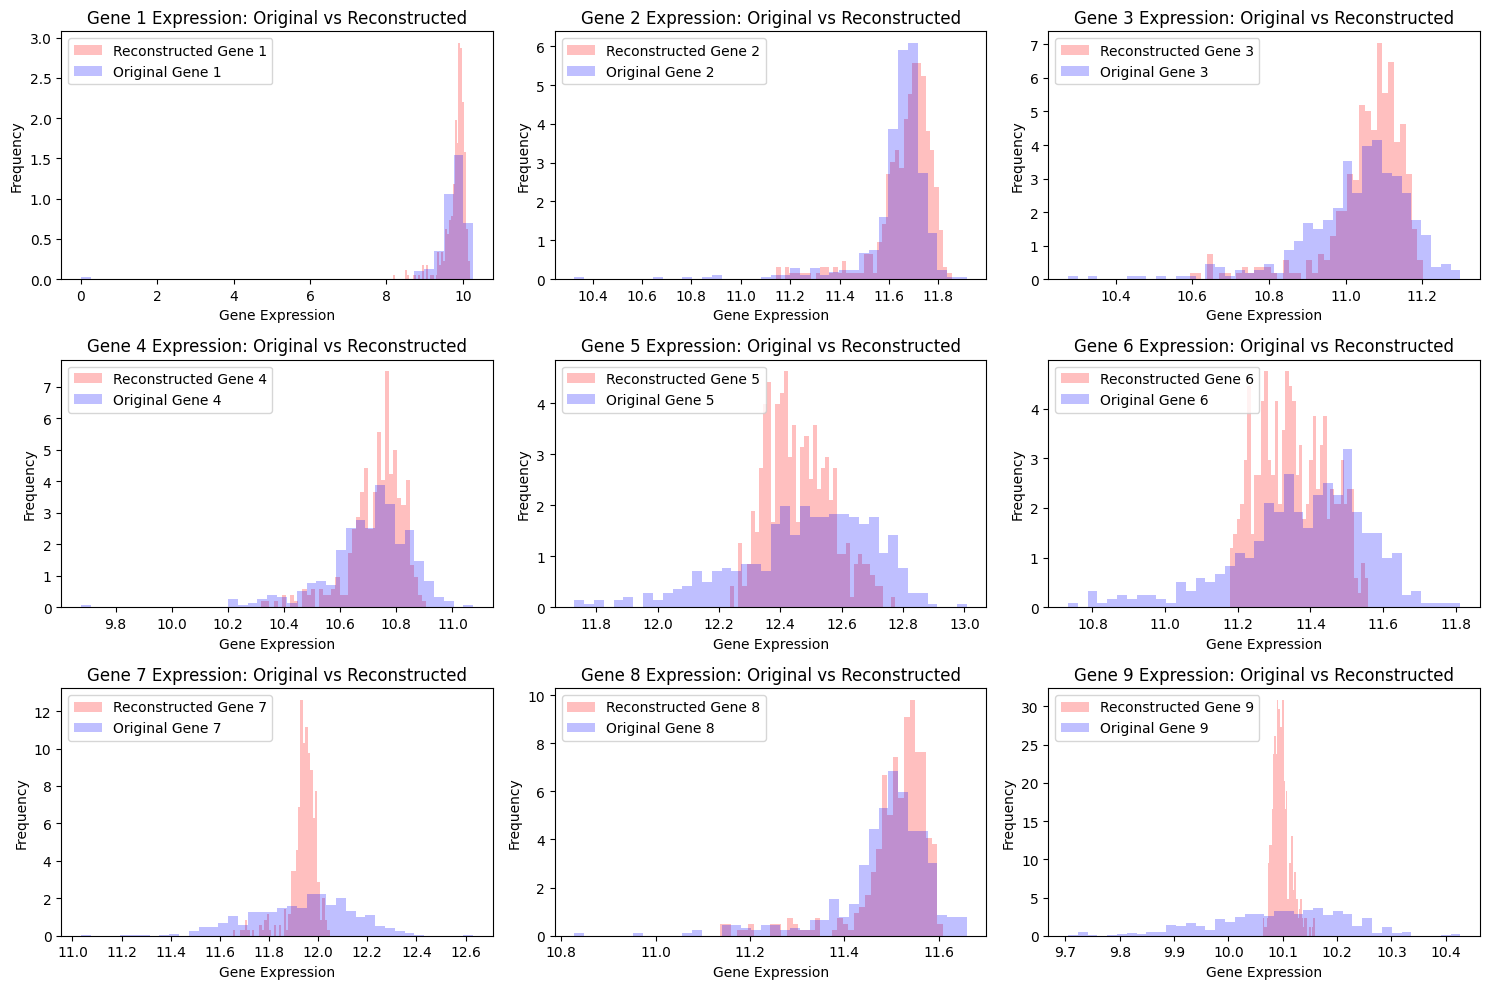

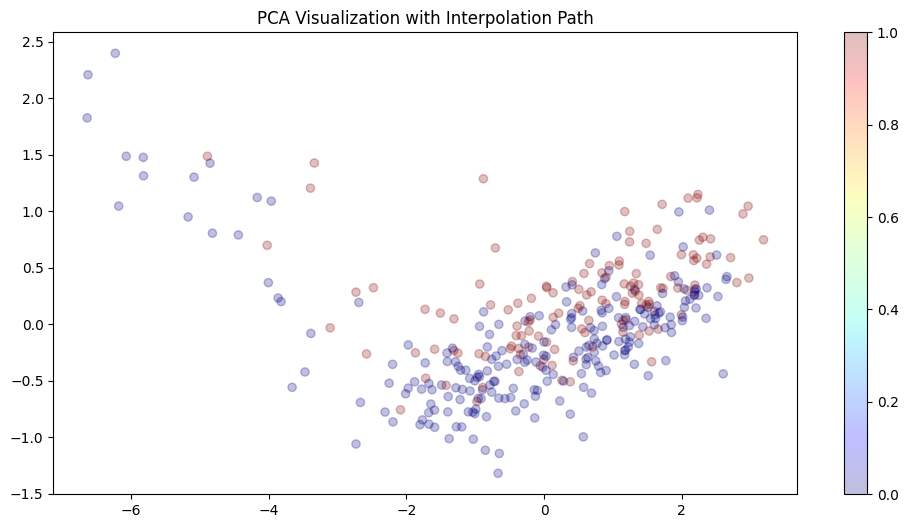

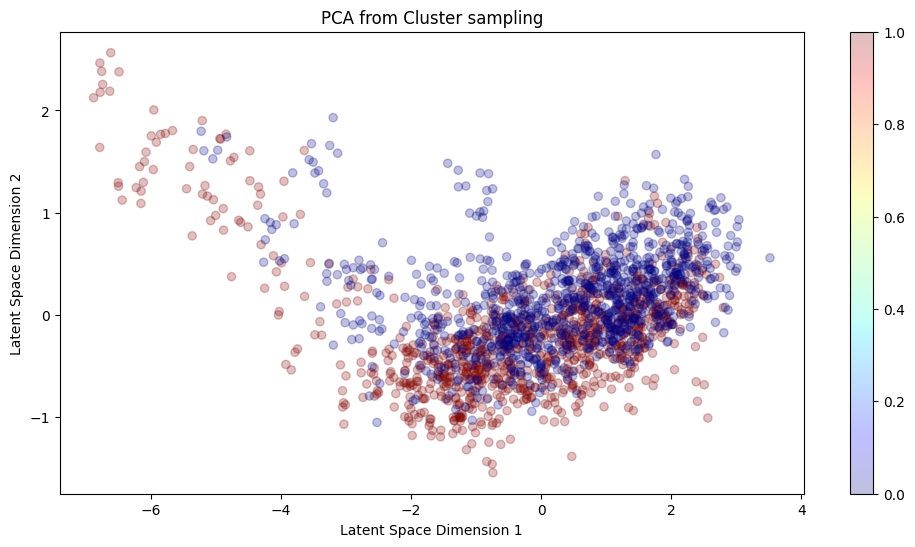

Epoch [101/1000], Recon : 0.0159, KL : 9.9288, Ortho : 337.7066, Class: 0.6104, Accuracy: 66.95%
Epoch [102/1000], Recon : 0.0159, KL : 10.7499, Ortho : 379.6064, Class: 0.6177, Accuracy: 67.80%
Epoch [103/1000], Recon : 0.0160, KL : 10.7692, Ortho : 376.4605, Class: 0.6030, Accuracy: 67.23%
Epoch [104/1000], Recon : 0.0154, KL : 10.0711, Ortho : 329.3545, Class: 0.6234, Accuracy: 64.41%
Epoch [105/1000], Recon : 0.0158, KL : 10.5242, Ortho : 346.5312, Class: 0.6101, Accuracy: 66.10%
Epoch [106/1000], Recon : 0.0160, KL : 10.7200, Ortho : 358.6744, Class: 0.6164, Accuracy: 68.64%
Epoch [107/1000], Recon : 0.0157, KL : 10.6700, Ortho : 349.7352, Class: 0.6032, Accuracy: 64.12%
Epoch [108/1000], Recon : 0.0158, KL : 10.9309, Ortho : 369.0943, Class: 0.5821, Accuracy: 68.93%
Epoch [109/1000], Recon : 0.0158, KL : 10.7328, Ortho : 349.8226, Class: 0.6153, Accuracy: 68.93%
Epoch [110/1000], Recon : 0.0159, KL : 10.4921, Ortho : 315.2542, Class: 0.5872, Accuracy: 67.80%
Epoch [111/1000], Rec

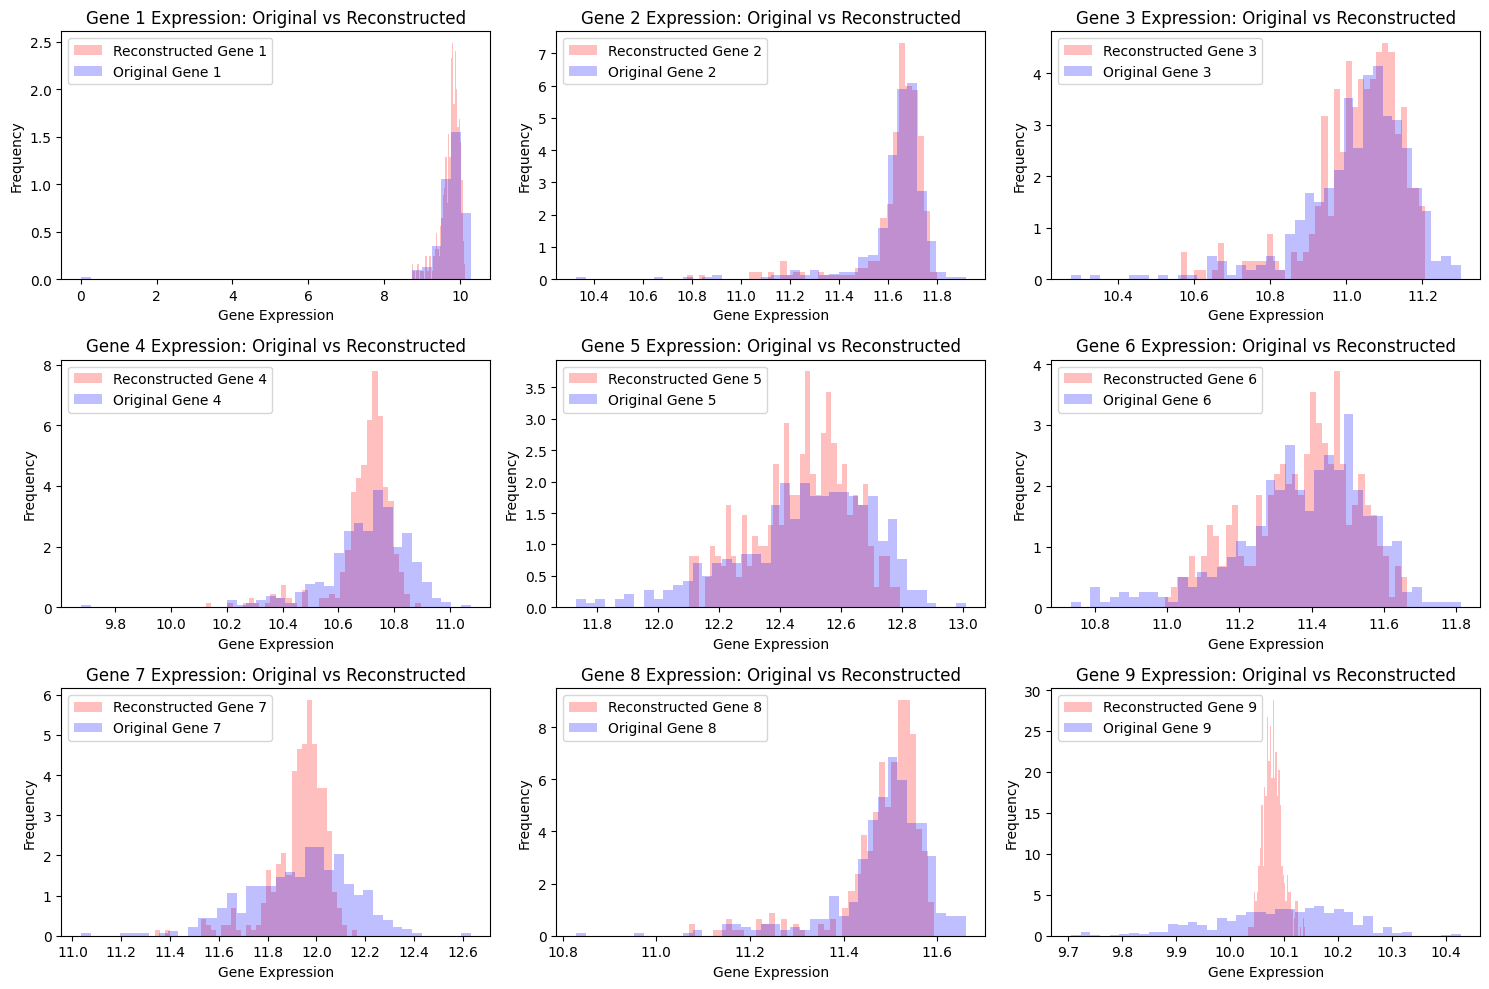

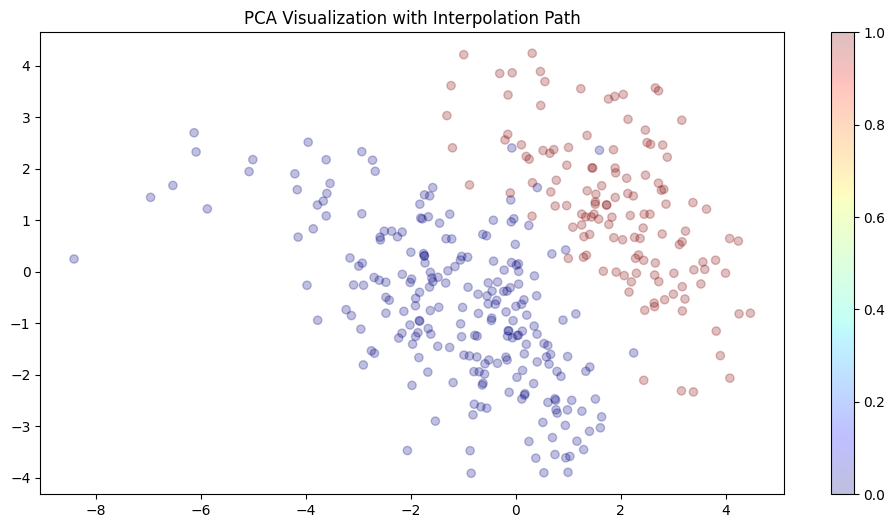

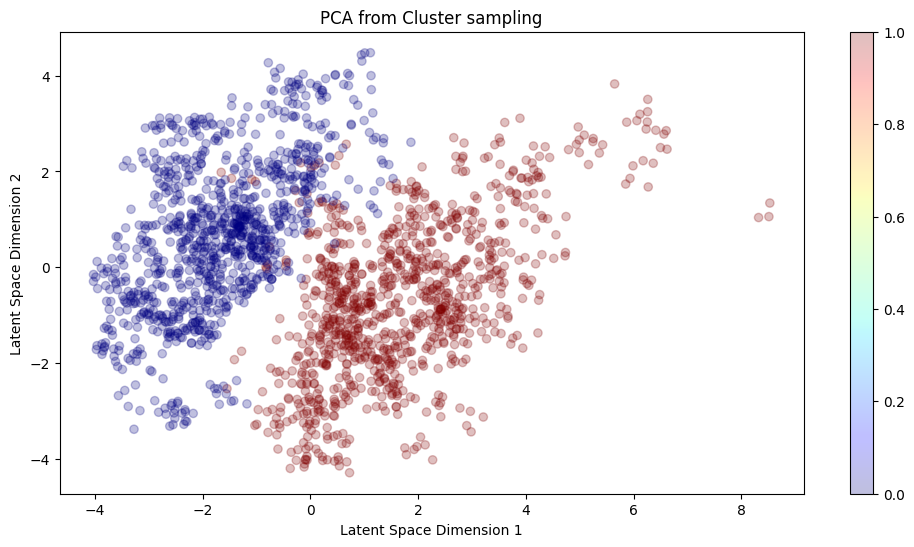

Epoch [201/1000], Recon : 0.0140, KL : 13.5828, Ortho : 438.9384, Class: 0.3190, Accuracy: 88.14%
Epoch [202/1000], Recon : 0.0139, KL : 13.2443, Ortho : 440.5264, Class: 0.3547, Accuracy: 79.10%
Epoch [203/1000], Recon : 0.0141, KL : 12.4777, Ortho : 359.5389, Class: 0.2617, Accuracy: 92.66%
Epoch [204/1000], Recon : 0.0142, KL : 12.1116, Ortho : 328.5196, Class: 0.2482, Accuracy: 97.18%
Epoch [205/1000], Recon : 0.0139, KL : 12.4122, Ortho : 348.8499, Class: 0.2422, Accuracy: 95.76%
Epoch [206/1000], Recon : 0.0139, KL : 12.3988, Ortho : 333.1528, Class: 0.2528, Accuracy: 97.18%
Epoch [207/1000], Recon : 0.0141, KL : 12.4817, Ortho : 341.3574, Class: 0.2349, Accuracy: 95.48%
Epoch [208/1000], Recon : 0.0138, KL : 12.5100, Ortho : 341.6878, Class: 0.2378, Accuracy: 95.48%
Epoch [209/1000], Recon : 0.0142, KL : 12.7410, Ortho : 348.3438, Class: 0.2469, Accuracy: 95.76%
Epoch [210/1000], Recon : 0.0139, KL : 13.4265, Ortho : 421.7550, Class: 0.2652, Accuracy: 90.40%
Epoch [211/1000], Re

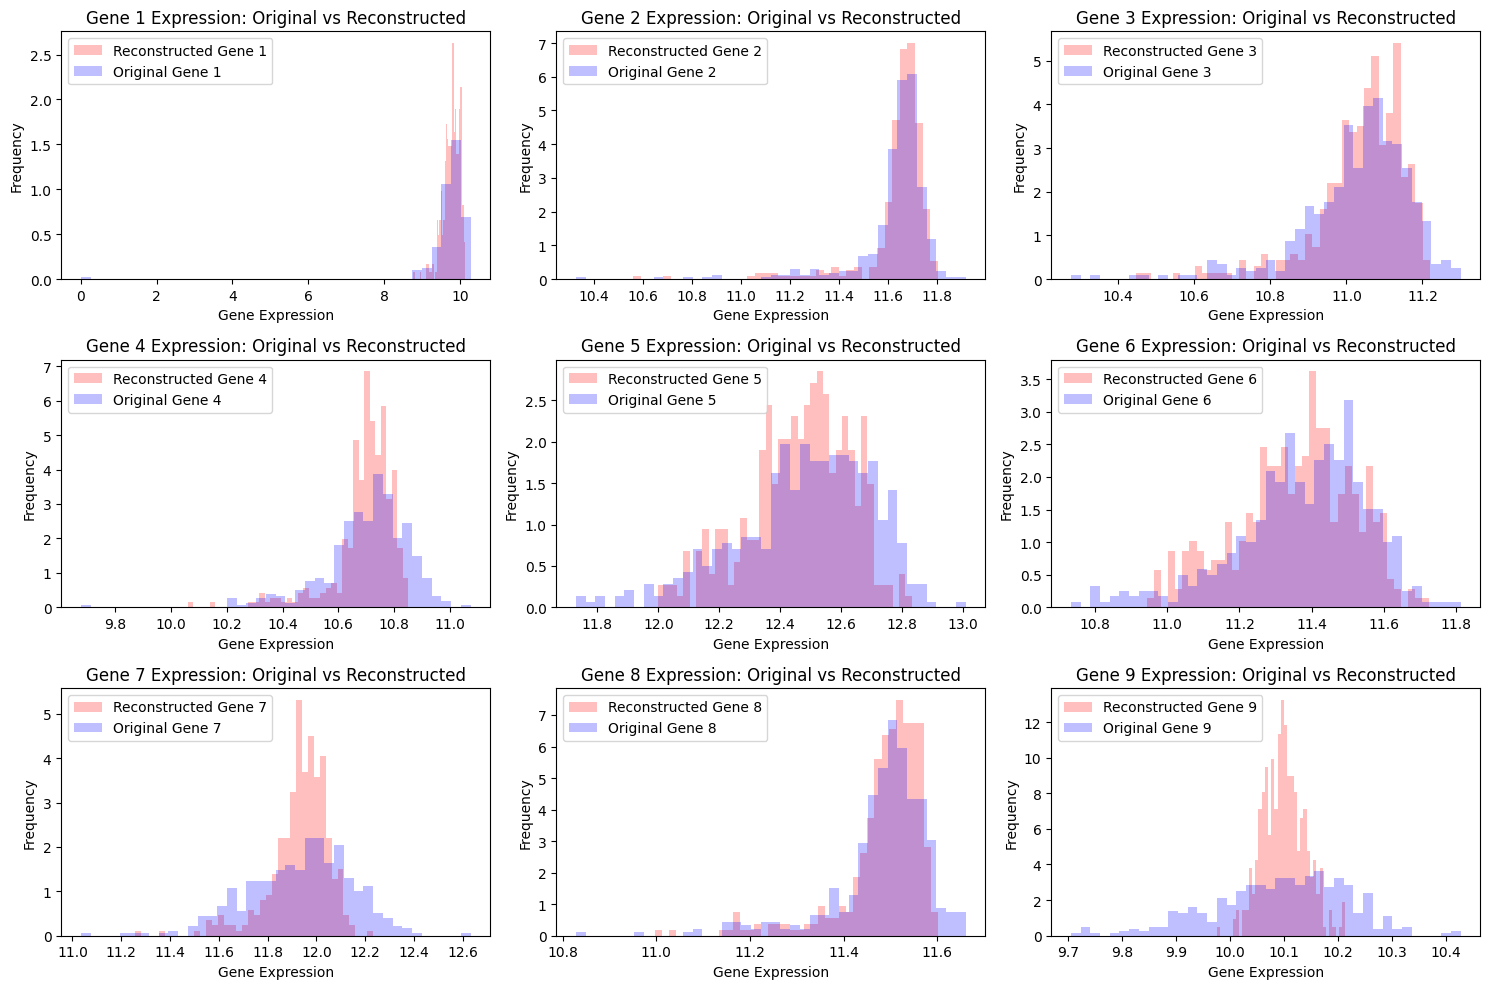

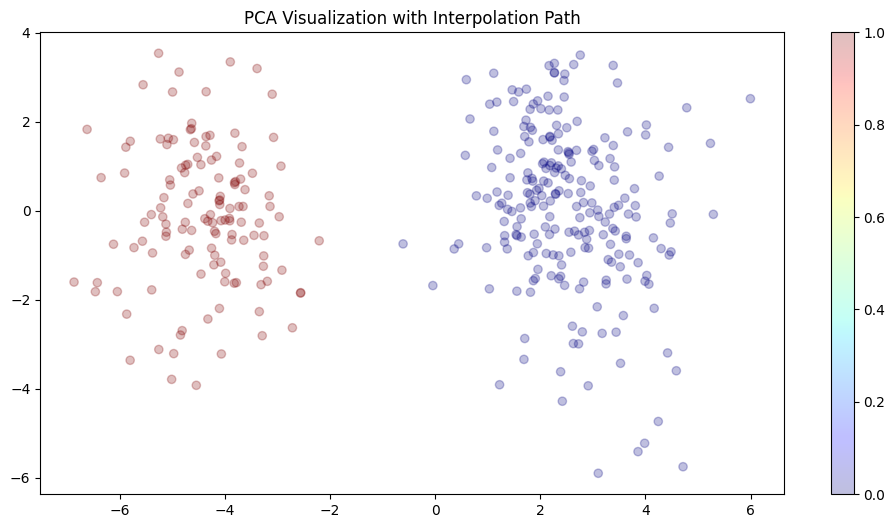

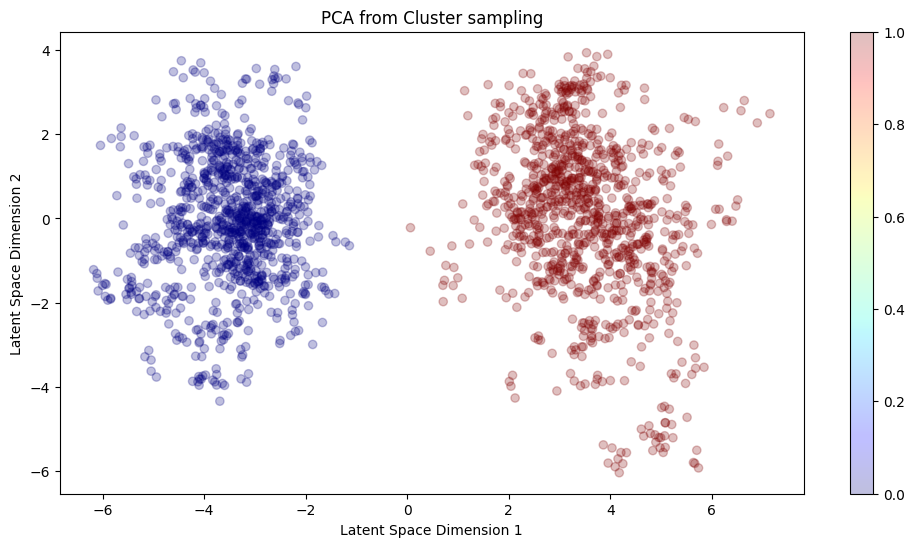

Epoch [301/1000], Recon : 0.0133, KL : 16.3854, Ortho : 653.6522, Class: 0.0467, Accuracy: 100.00%
Epoch [302/1000], Recon : 0.0133, KL : 16.2779, Ortho : 659.2106, Class: 0.0514, Accuracy: 100.00%
Epoch [303/1000], Recon : 0.0132, KL : 16.2404, Ortho : 656.4648, Class: 0.0690, Accuracy: 99.72%
Epoch [304/1000], Recon : 0.0128, KL : 15.9706, Ortho : 622.2711, Class: 0.0638, Accuracy: 100.00%
Epoch [305/1000], Recon : 0.0132, KL : 16.0804, Ortho : 645.8229, Class: 0.0440, Accuracy: 99.72%
Epoch [306/1000], Recon : 0.0130, KL : 15.8372, Ortho : 624.5146, Class: 0.0363, Accuracy: 100.00%
Epoch [307/1000], Recon : 0.0133, KL : 16.0885, Ortho : 647.1159, Class: 0.0427, Accuracy: 99.44%
Epoch [308/1000], Recon : 0.0131, KL : 15.9008, Ortho : 640.6360, Class: 0.0469, Accuracy: 100.00%
Epoch [309/1000], Recon : 0.0129, KL : 15.7907, Ortho : 630.9877, Class: 0.0363, Accuracy: 100.00%
Epoch [310/1000], Recon : 0.0133, KL : 15.9862, Ortho : 640.7848, Class: 0.0415, Accuracy: 100.00%
Epoch [311/10

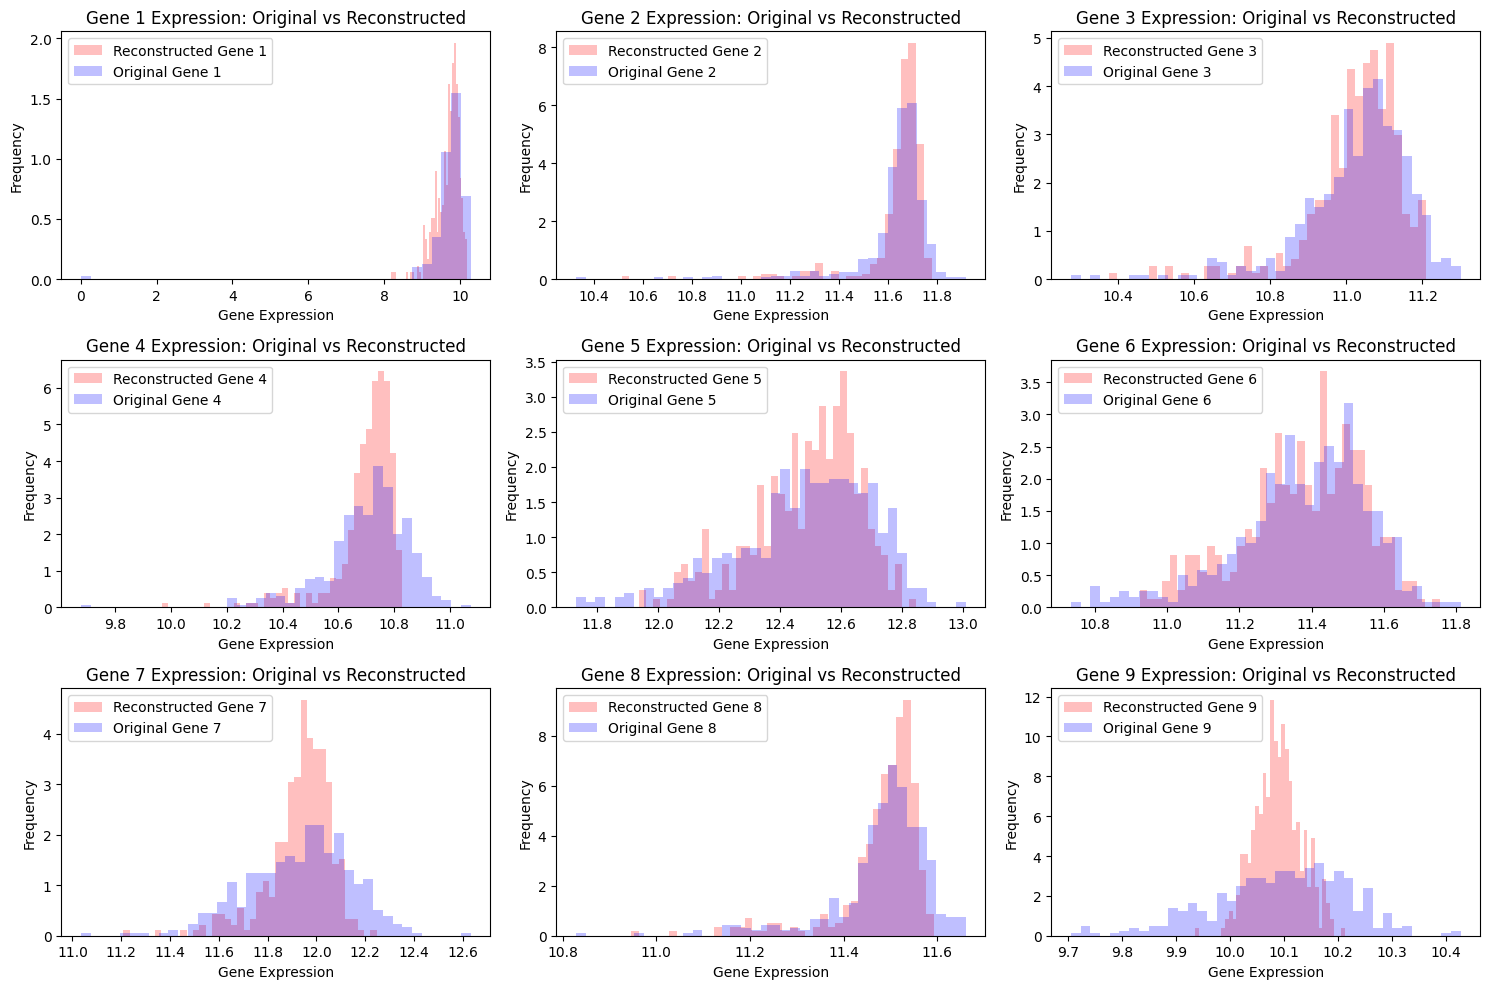

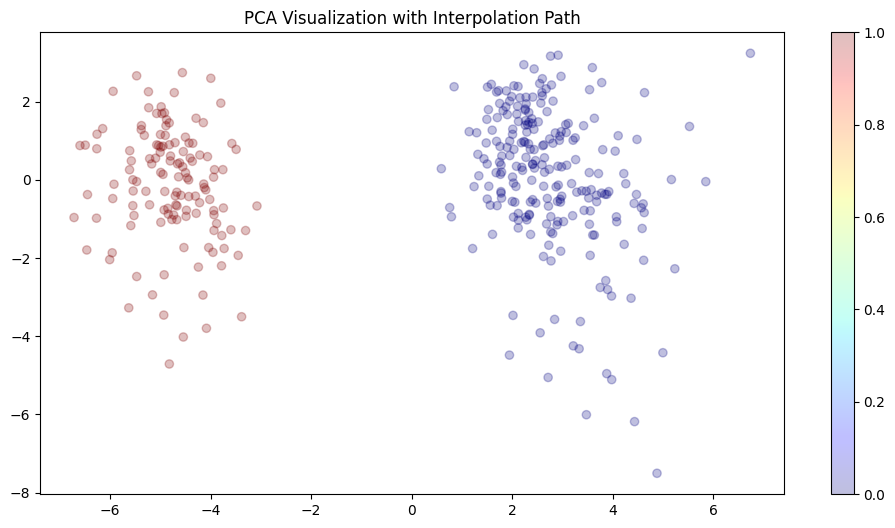

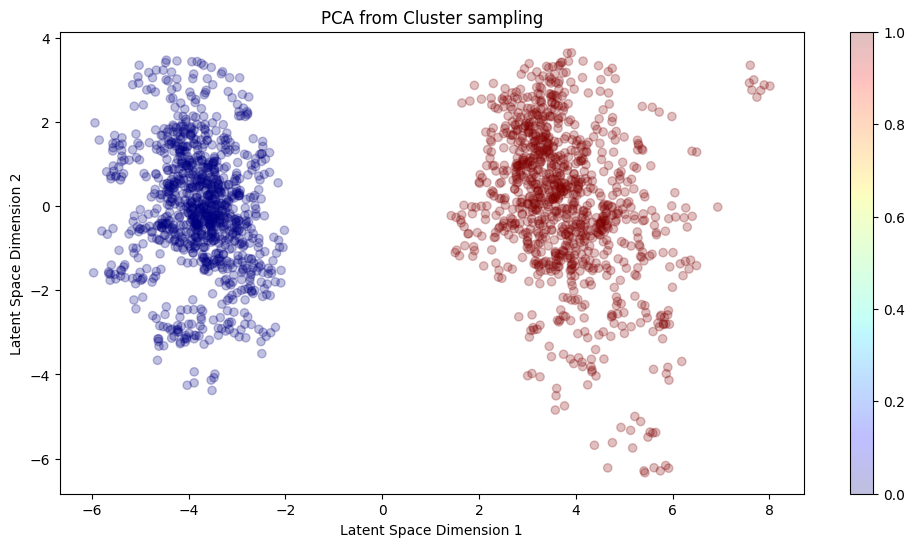

Epoch [401/1000], Recon : 0.0123, KL : 15.7806, Ortho : 685.8843, Class: 0.0169, Accuracy: 100.00%
Epoch [402/1000], Recon : 0.0122, KL : 16.0861, Ortho : 684.6634, Class: 0.0170, Accuracy: 100.00%
Epoch [403/1000], Recon : 0.0127, KL : 16.0197, Ortho : 688.4301, Class: 0.0172, Accuracy: 100.00%
Epoch [404/1000], Recon : 0.0123, KL : 15.9326, Ortho : 692.6027, Class: 0.0183, Accuracy: 100.00%
Epoch [405/1000], Recon : 0.0126, KL : 15.9579, Ortho : 696.4809, Class: 0.0188, Accuracy: 100.00%
Epoch [406/1000], Recon : 0.0129, KL : 15.7955, Ortho : 686.5173, Class: 0.0182, Accuracy: 100.00%
Epoch [407/1000], Recon : 0.0132, KL : 15.7966, Ortho : 694.4845, Class: 0.0216, Accuracy: 100.00%
Epoch [408/1000], Recon : 0.0126, KL : 16.0346, Ortho : 716.8091, Class: 0.0227, Accuracy: 100.00%
Epoch [409/1000], Recon : 0.0127, KL : 15.9158, Ortho : 701.2100, Class: 0.0242, Accuracy: 100.00%
Epoch [410/1000], Recon : 0.0132, KL : 15.8908, Ortho : 704.2162, Class: 0.0166, Accuracy: 100.00%
Epoch [411

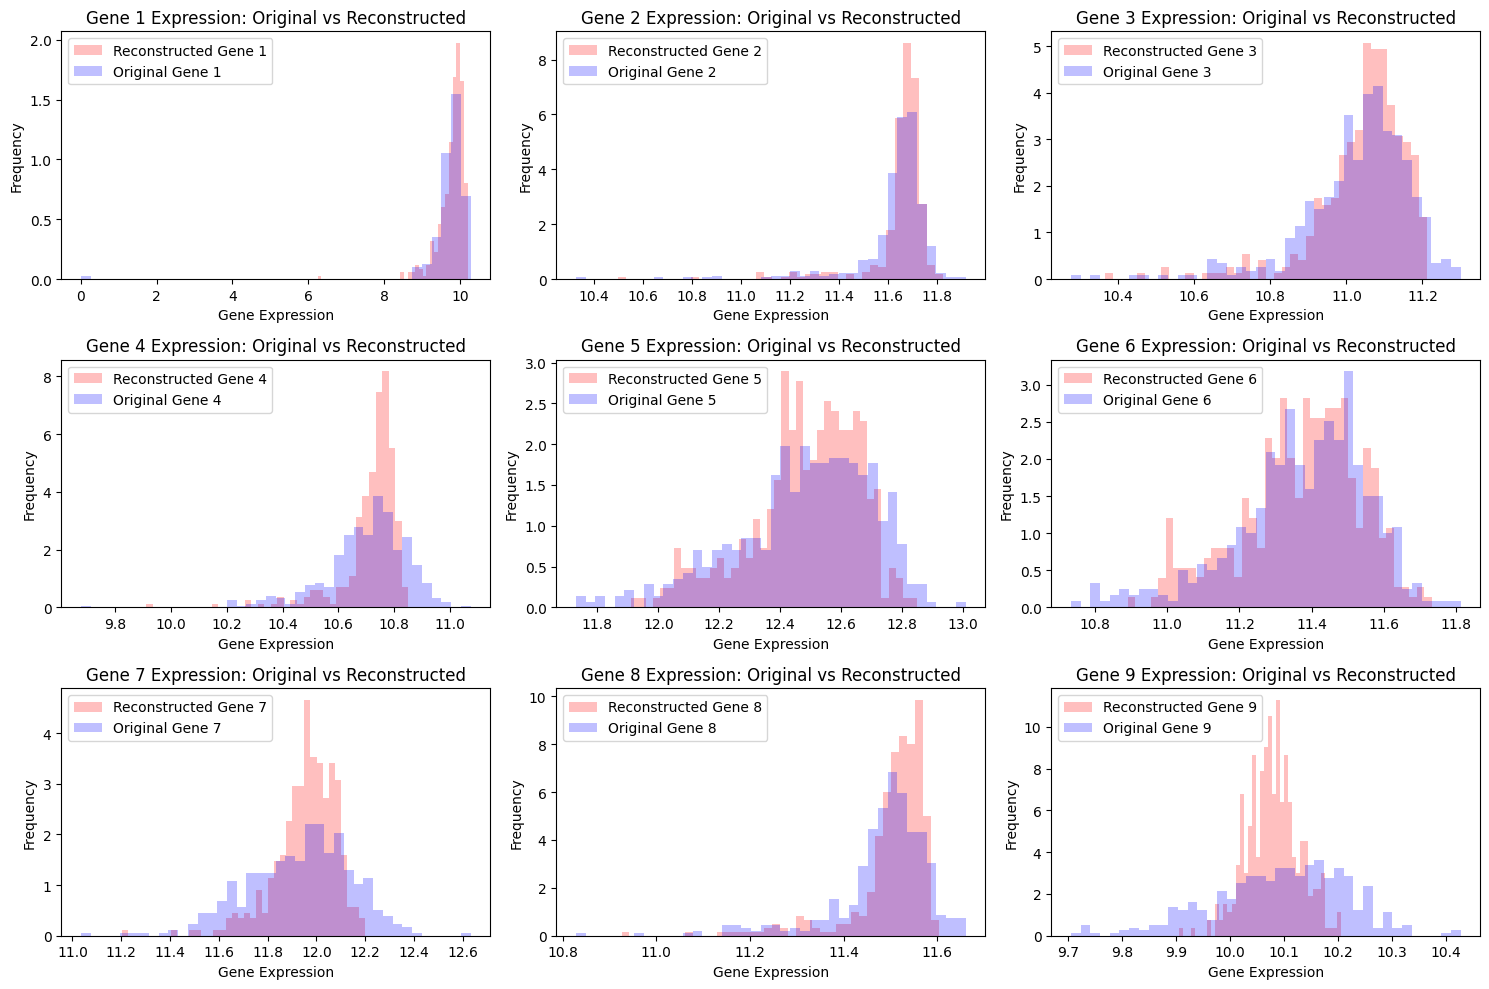

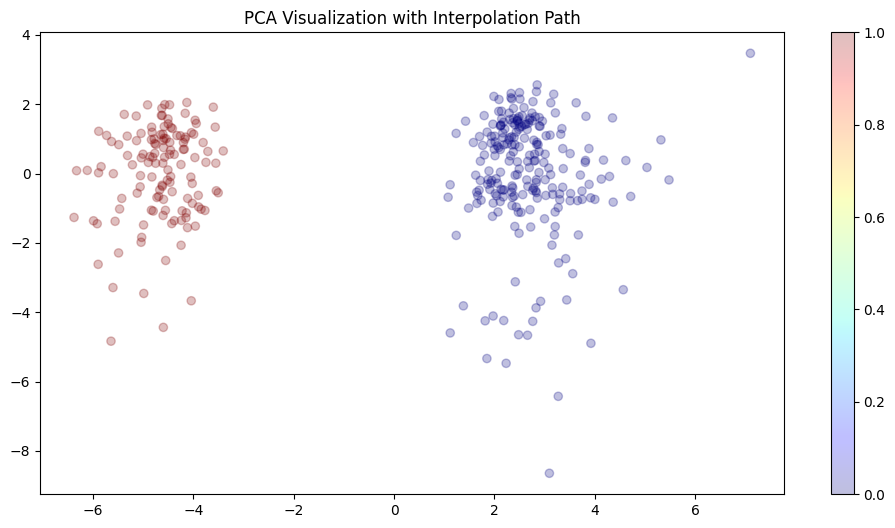

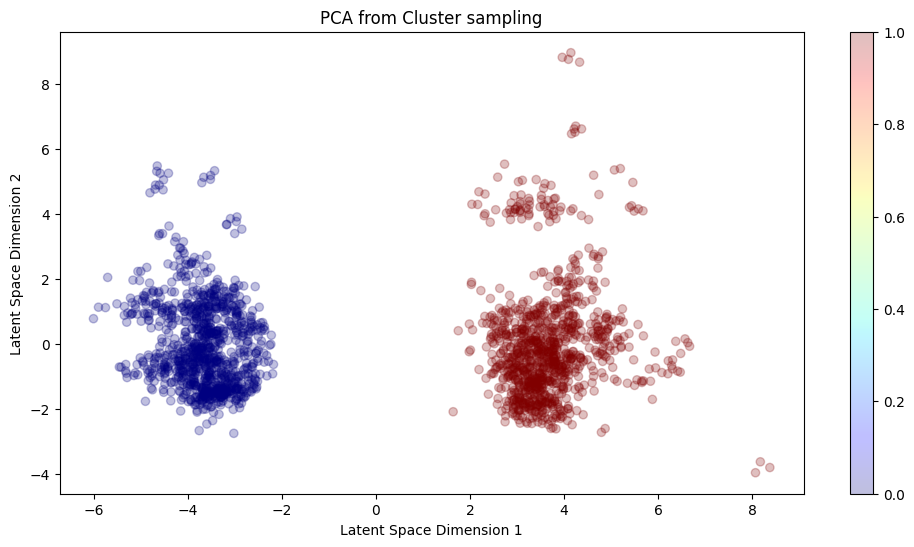

Epoch [501/1000], Recon : 0.0123, KL : 14.9354, Ortho : 628.1851, Class: 0.0122, Accuracy: 100.00%
Epoch [502/1000], Recon : 0.0130, KL : 15.1491, Ortho : 644.9637, Class: 0.0150, Accuracy: 100.00%
Epoch [503/1000], Recon : 0.0122, KL : 14.9311, Ortho : 630.4491, Class: 0.0121, Accuracy: 100.00%
Epoch [504/1000], Recon : 0.0128, KL : 15.0736, Ortho : 631.4395, Class: 0.0122, Accuracy: 100.00%
Epoch [505/1000], Recon : 0.0120, KL : 14.8728, Ortho : 624.1390, Class: 0.0136, Accuracy: 100.00%
Epoch [506/1000], Recon : 0.0119, KL : 15.0962, Ortho : 635.6532, Class: 0.0117, Accuracy: 100.00%
Epoch [507/1000], Recon : 0.0120, KL : 15.0850, Ortho : 647.4128, Class: 0.0146, Accuracy: 100.00%
Epoch [508/1000], Recon : 0.0121, KL : 15.1010, Ortho : 635.6813, Class: 0.0150, Accuracy: 100.00%
Epoch [509/1000], Recon : 0.0123, KL : 14.9367, Ortho : 616.2489, Class: 0.0132, Accuracy: 100.00%
Epoch [510/1000], Recon : 0.0121, KL : 15.0231, Ortho : 620.2402, Class: 0.0121, Accuracy: 100.00%
Epoch [511

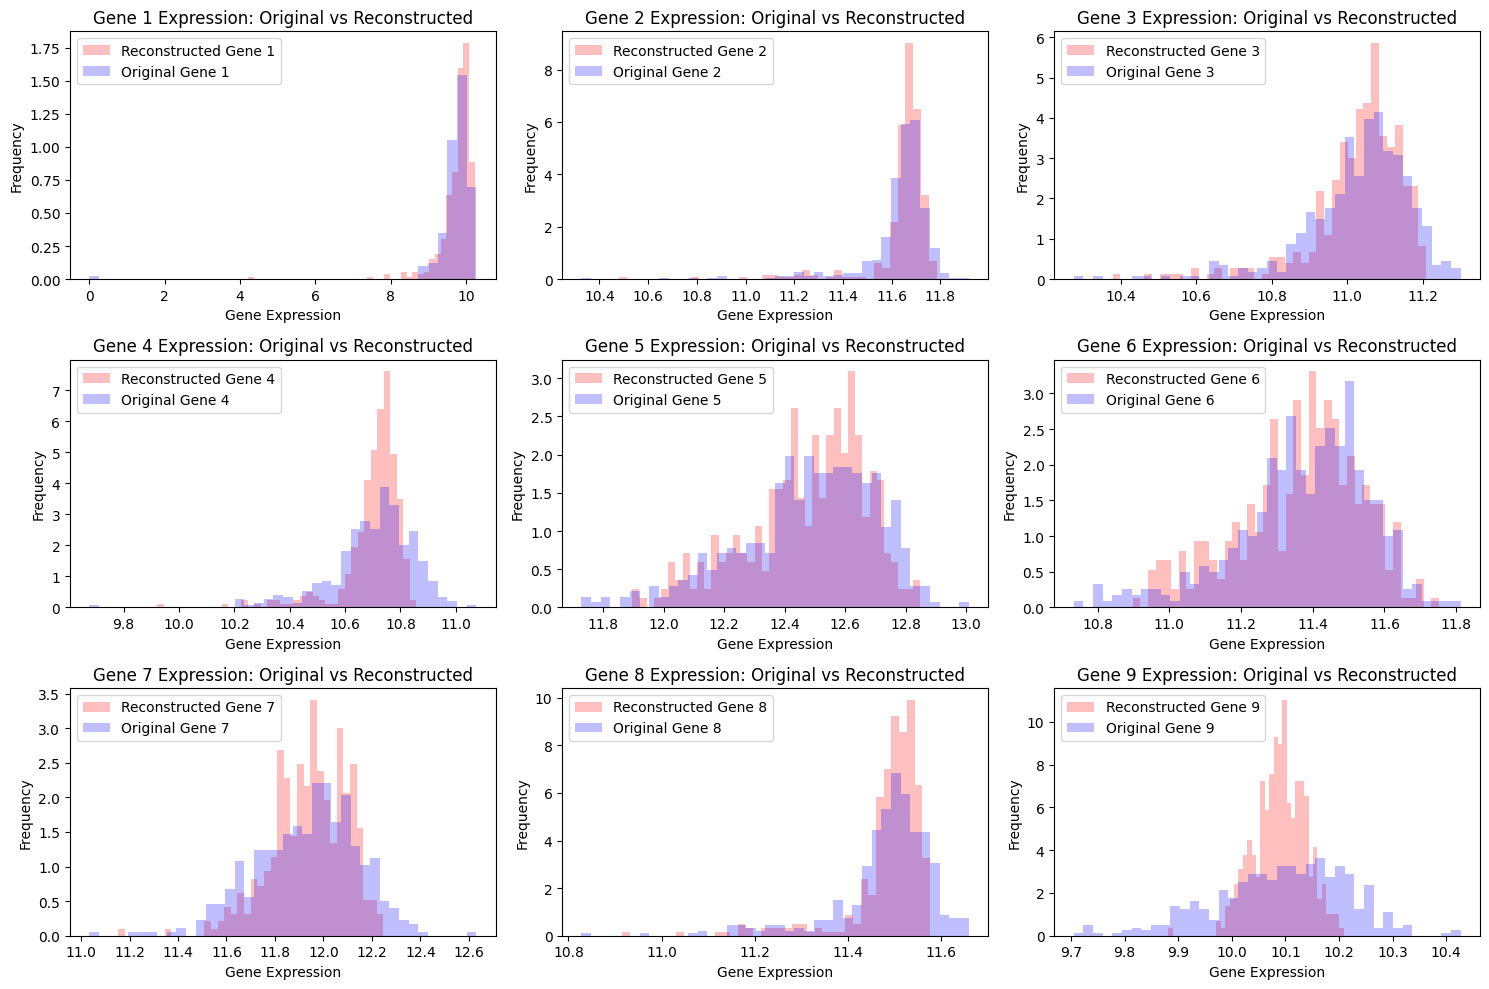

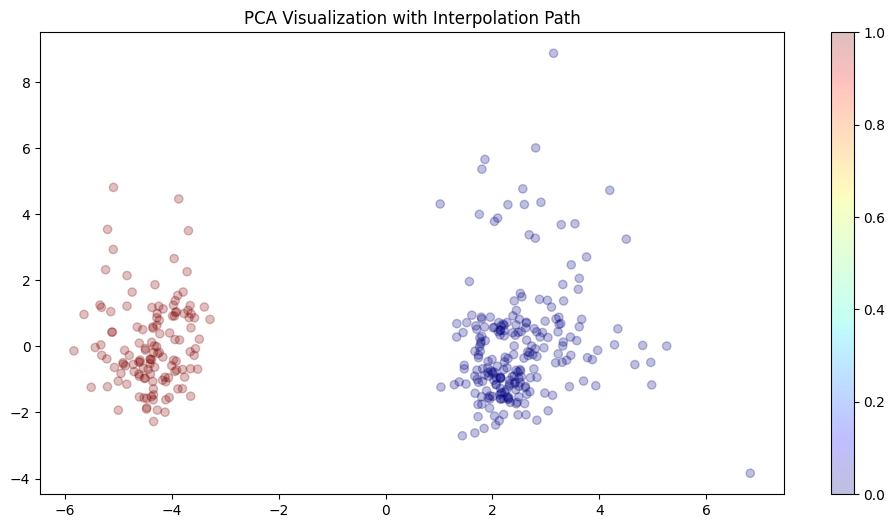

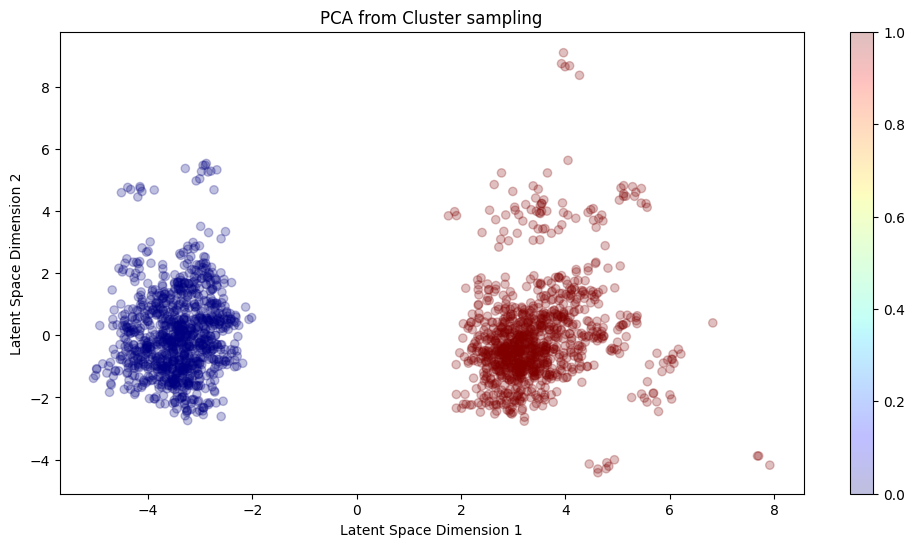

Epoch [601/1000], Recon : 0.0113, KL : 15.2777, Ortho : 570.5176, Class: 0.0131, Accuracy: 100.00%
Epoch [602/1000], Recon : 0.0112, KL : 15.2638, Ortho : 564.0670, Class: 0.0105, Accuracy: 100.00%
Epoch [603/1000], Recon : 0.0111, KL : 15.3512, Ortho : 574.1418, Class: 0.0118, Accuracy: 100.00%
Epoch [604/1000], Recon : 0.0113, KL : 15.2511, Ortho : 566.1043, Class: 0.0102, Accuracy: 100.00%
Epoch [605/1000], Recon : 0.0112, KL : 15.4091, Ortho : 577.3344, Class: 0.0119, Accuracy: 100.00%
Epoch [606/1000], Recon : 0.0110, KL : 15.3052, Ortho : 561.6350, Class: 0.0106, Accuracy: 100.00%
Epoch [607/1000], Recon : 0.0111, KL : 15.3561, Ortho : 569.7978, Class: 0.0129, Accuracy: 100.00%
Epoch [608/1000], Recon : 0.0115, KL : 15.2227, Ortho : 570.9213, Class: 0.0102, Accuracy: 100.00%
Epoch [609/1000], Recon : 0.0114, KL : 15.2001, Ortho : 567.7382, Class: 0.0136, Accuracy: 100.00%
Epoch [610/1000], Recon : 0.0119, KL : 15.1564, Ortho : 572.5955, Class: 0.0126, Accuracy: 100.00%
Epoch [611

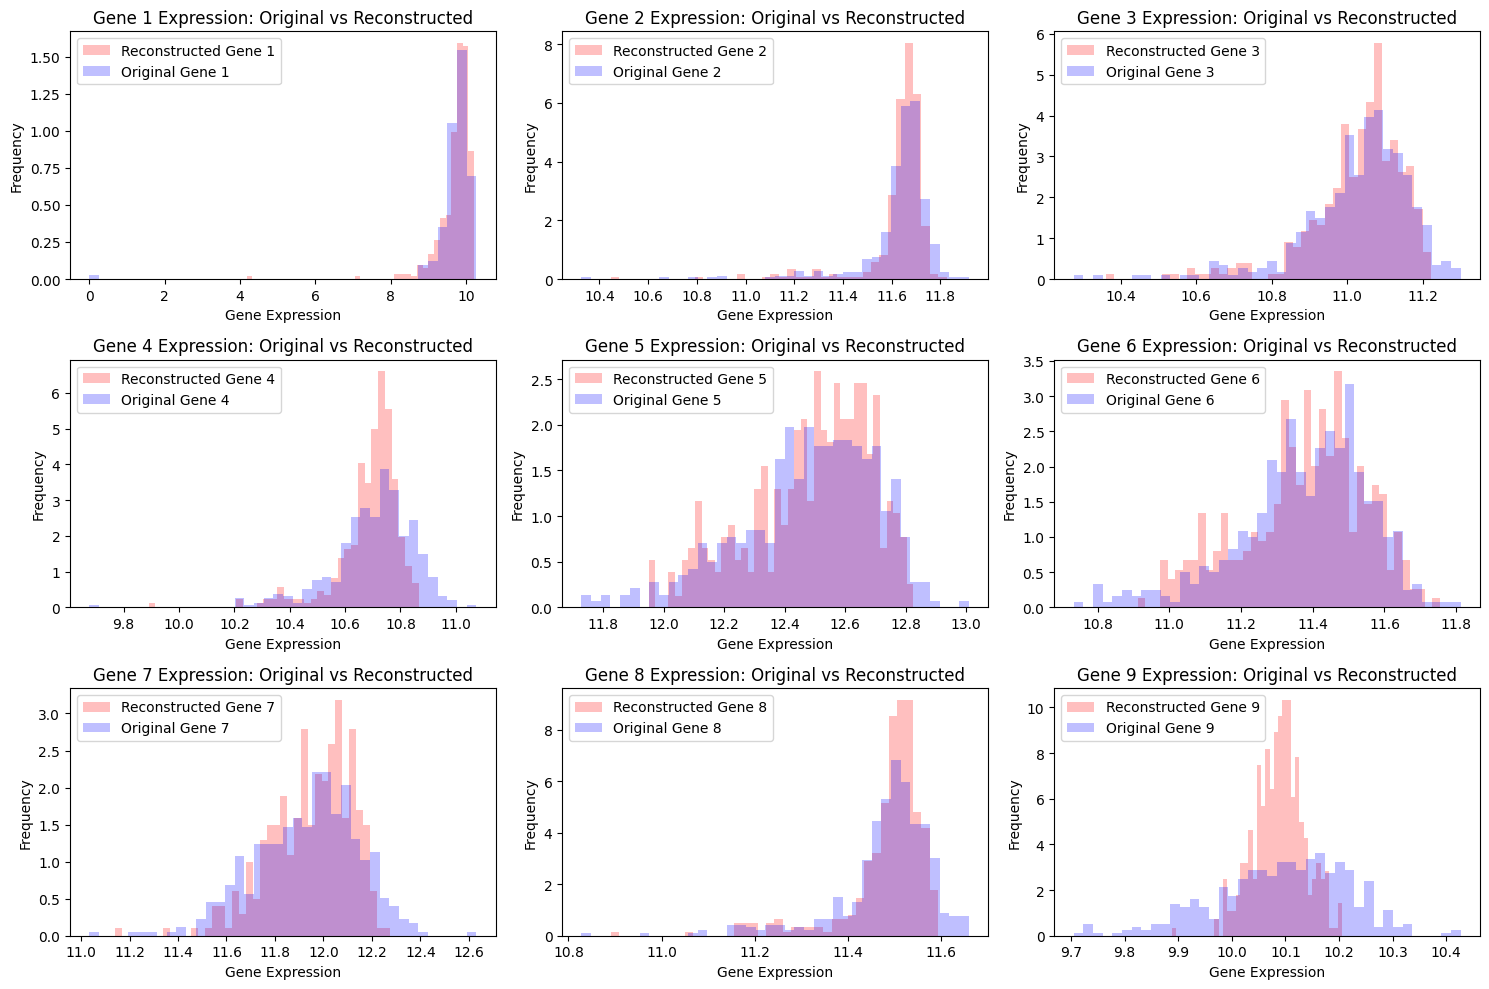

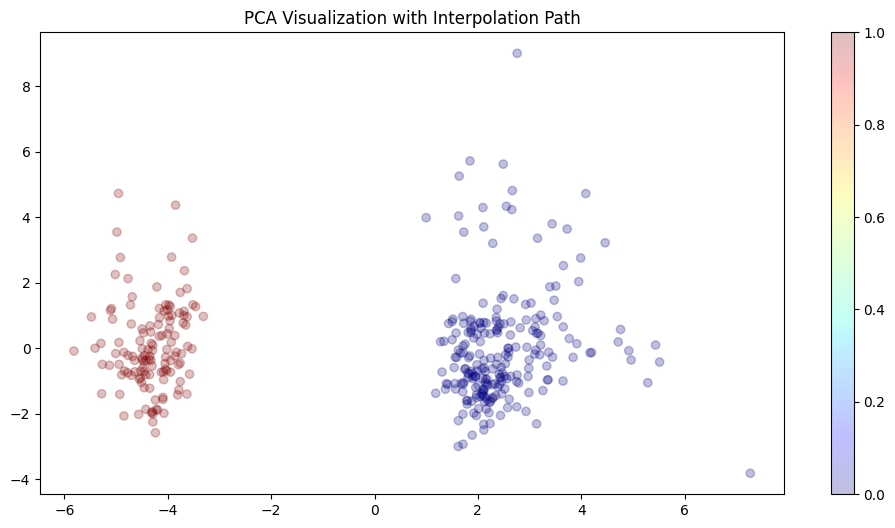

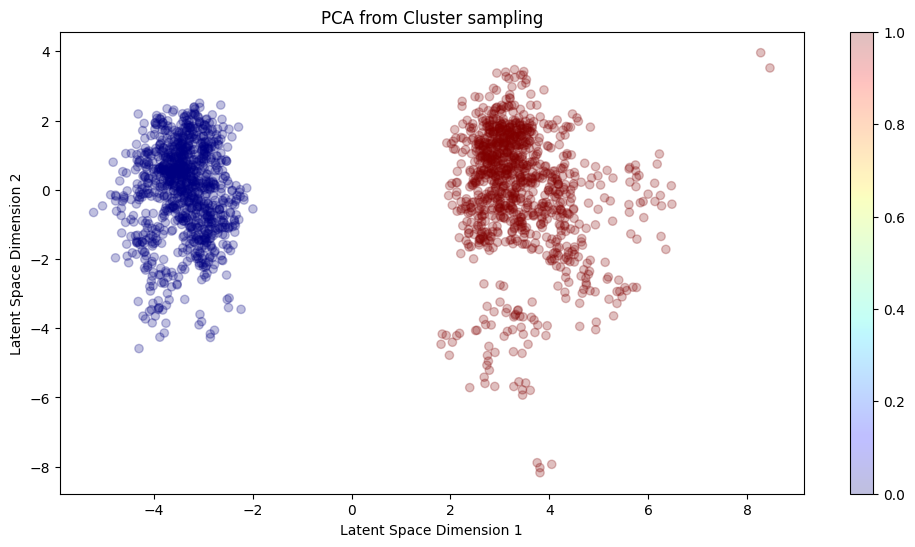

Epoch [701/1000], Recon : 0.0107, KL : 15.1921, Ortho : 558.9042, Class: 0.0068, Accuracy: 100.00%
Epoch [702/1000], Recon : 0.0110, KL : 15.1070, Ortho : 559.3864, Class: 0.0080, Accuracy: 100.00%
Epoch [703/1000], Recon : 0.0110, KL : 15.2248, Ortho : 566.8328, Class: 0.0089, Accuracy: 100.00%
Epoch [704/1000], Recon : 0.0108, KL : 15.2719, Ortho : 571.8651, Class: 0.0105, Accuracy: 100.00%
Epoch [705/1000], Recon : 0.0109, KL : 15.1543, Ortho : 555.9586, Class: 0.0105, Accuracy: 100.00%
Epoch [706/1000], Recon : 0.0112, KL : 14.9751, Ortho : 544.0666, Class: 0.0076, Accuracy: 100.00%
Epoch [707/1000], Recon : 0.0111, KL : 15.0918, Ortho : 550.0745, Class: 0.0096, Accuracy: 100.00%
Epoch [708/1000], Recon : 0.0108, KL : 14.9751, Ortho : 540.4195, Class: 0.0087, Accuracy: 100.00%
Epoch [709/1000], Recon : 0.0112, KL : 14.8774, Ortho : 536.7836, Class: 0.0087, Accuracy: 100.00%
Epoch [710/1000], Recon : 0.0109, KL : 15.0057, Ortho : 548.4596, Class: 0.0100, Accuracy: 100.00%
Epoch [711

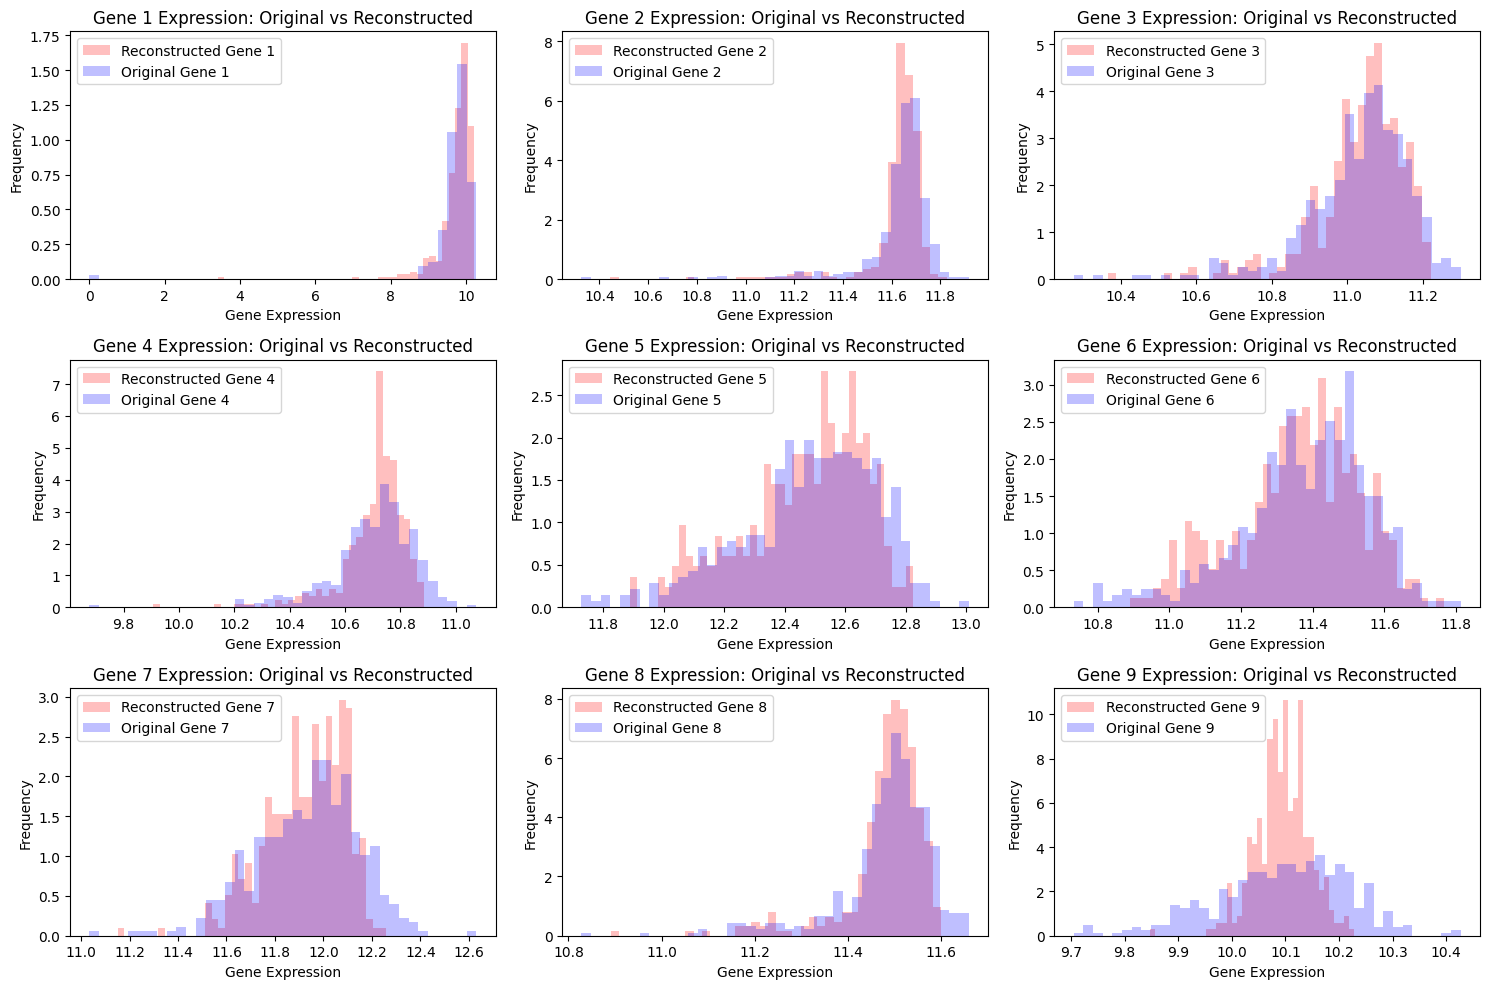

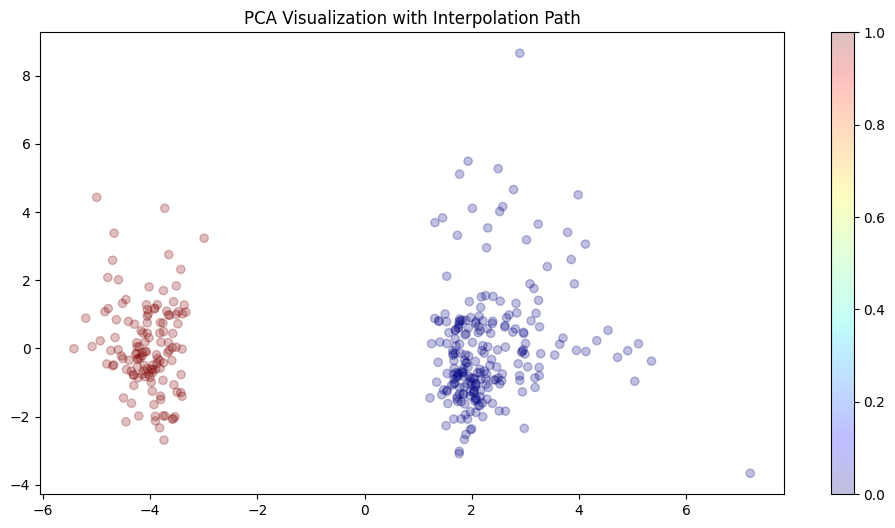

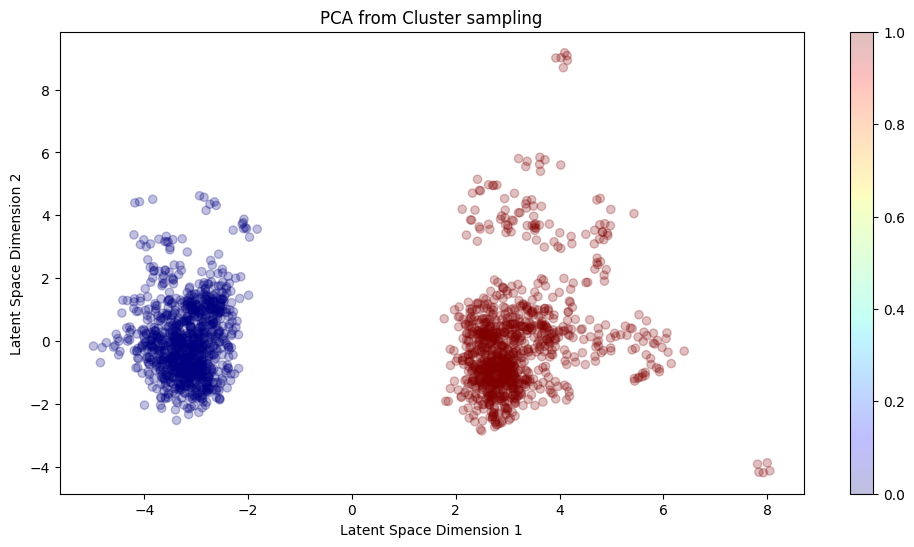

Epoch [801/1000], Recon : 0.0106, KL : 14.6013, Ortho : 511.9641, Class: 0.0086, Accuracy: 100.00%
Epoch [802/1000], Recon : 0.0111, KL : 14.4431, Ortho : 500.5636, Class: 0.0056, Accuracy: 100.00%
Epoch [803/1000], Recon : 0.0109, KL : 14.5333, Ortho : 505.9430, Class: 0.0096, Accuracy: 100.00%
Epoch [804/1000], Recon : 0.0107, KL : 14.5838, Ortho : 504.3305, Class: 0.0107, Accuracy: 100.00%
Epoch [805/1000], Recon : 0.0109, KL : 14.5988, Ortho : 505.0297, Class: 0.0077, Accuracy: 100.00%
Epoch [806/1000], Recon : 0.0105, KL : 14.5840, Ortho : 511.0779, Class: 0.0076, Accuracy: 100.00%
Epoch [807/1000], Recon : 0.0105, KL : 14.6752, Ortho : 527.2569, Class: 0.0086, Accuracy: 100.00%
Epoch [808/1000], Recon : 0.0108, KL : 14.4019, Ortho : 512.7984, Class: 0.0085, Accuracy: 100.00%
Epoch [809/1000], Recon : 0.0103, KL : 14.1831, Ortho : 498.1688, Class: 0.0082, Accuracy: 100.00%
Epoch [810/1000], Recon : 0.0105, KL : 14.2902, Ortho : 497.5798, Class: 0.0093, Accuracy: 100.00%
Epoch [811

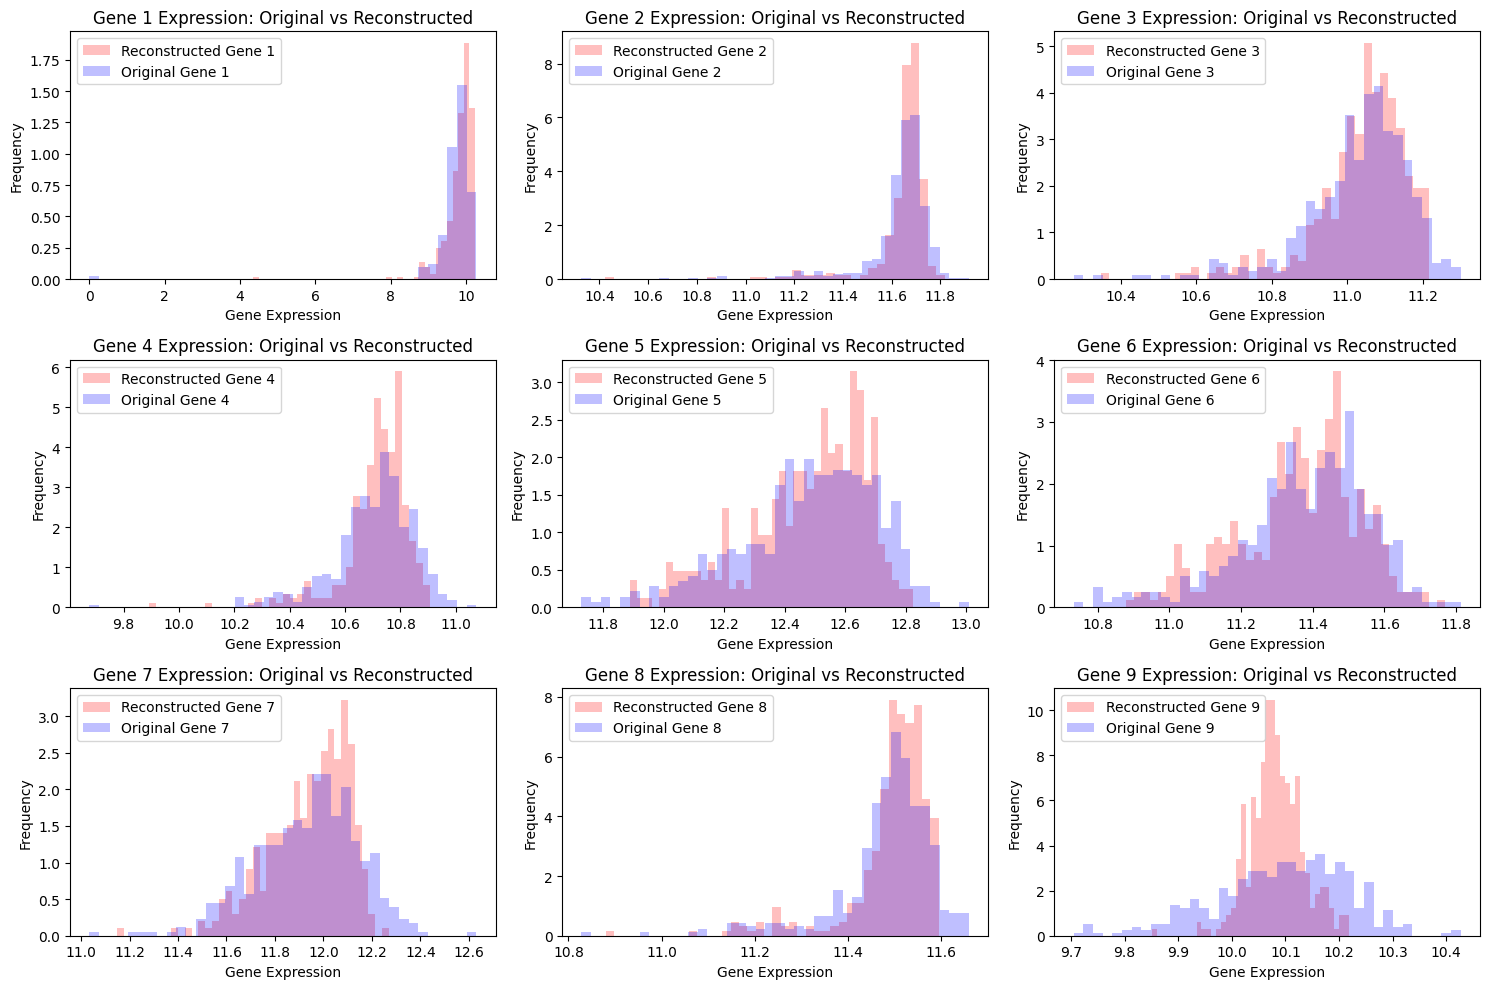

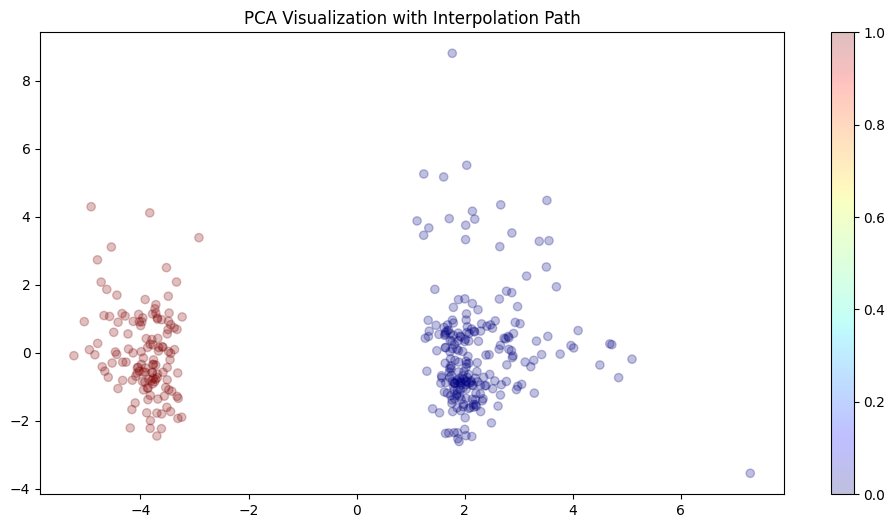

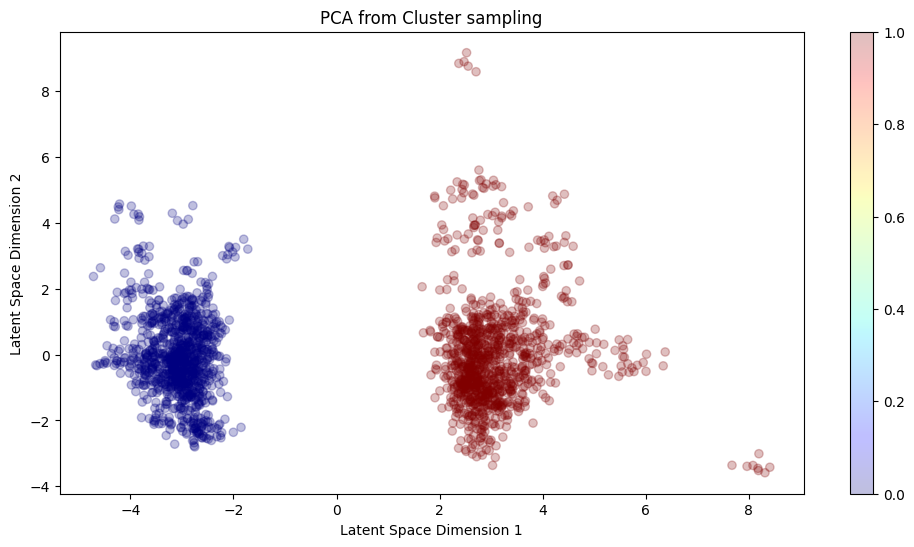

Epoch [901/1000], Recon : 0.0104, KL : 13.7840, Ortho : 447.1390, Class: 0.0122, Accuracy: 100.00%
Epoch [902/1000], Recon : 0.0103, KL : 14.6638, Ortho : 523.5192, Class: 0.0165, Accuracy: 100.00%
Epoch [903/1000], Recon : 0.0106, KL : 14.6722, Ortho : 528.2053, Class: 0.0134, Accuracy: 100.00%
Epoch [904/1000], Recon : 0.0106, KL : 14.6059, Ortho : 511.0286, Class: 0.0107, Accuracy: 100.00%
Epoch [905/1000], Recon : 0.0103, KL : 14.2287, Ortho : 478.7333, Class: 0.0078, Accuracy: 100.00%
Epoch [906/1000], Recon : 0.0102, KL : 14.3710, Ortho : 490.0063, Class: 0.0097, Accuracy: 100.00%
Epoch [907/1000], Recon : 0.0101, KL : 14.4415, Ortho : 489.9164, Class: 0.0056, Accuracy: 100.00%
Epoch [908/1000], Recon : 0.0100, KL : 14.2186, Ortho : 474.8645, Class: 0.0068, Accuracy: 100.00%
Epoch [909/1000], Recon : 0.0100, KL : 14.1758, Ortho : 478.8591, Class: 0.0097, Accuracy: 100.00%
Epoch [910/1000], Recon : 0.0103, KL : 14.1079, Ortho : 470.5678, Class: 0.0058, Accuracy: 100.00%
Epoch [911

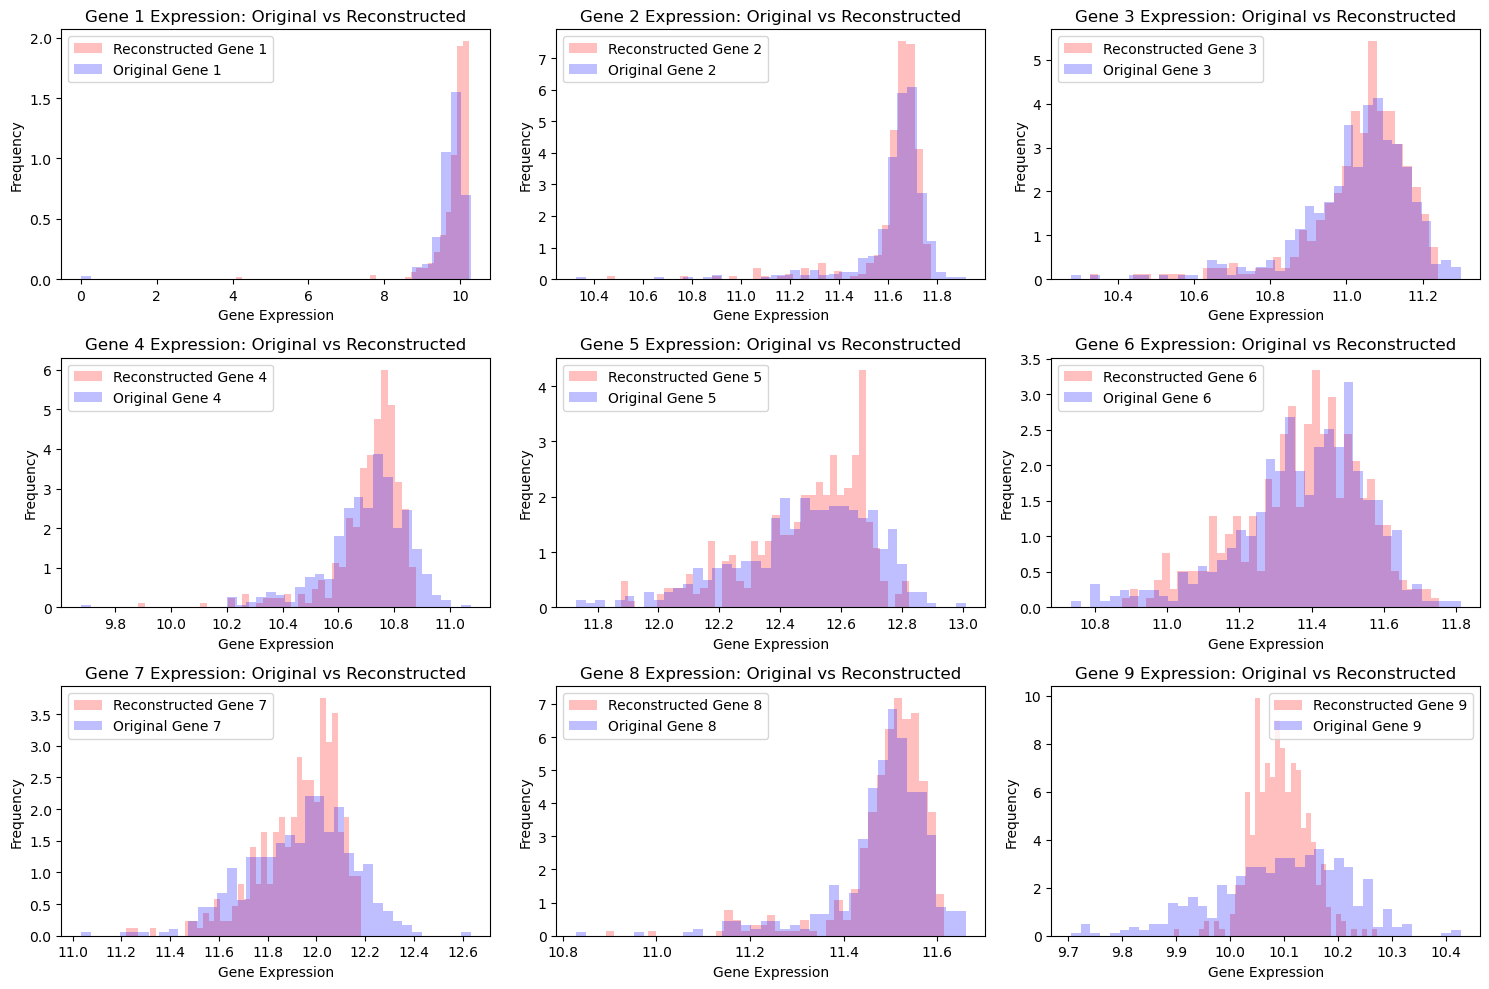

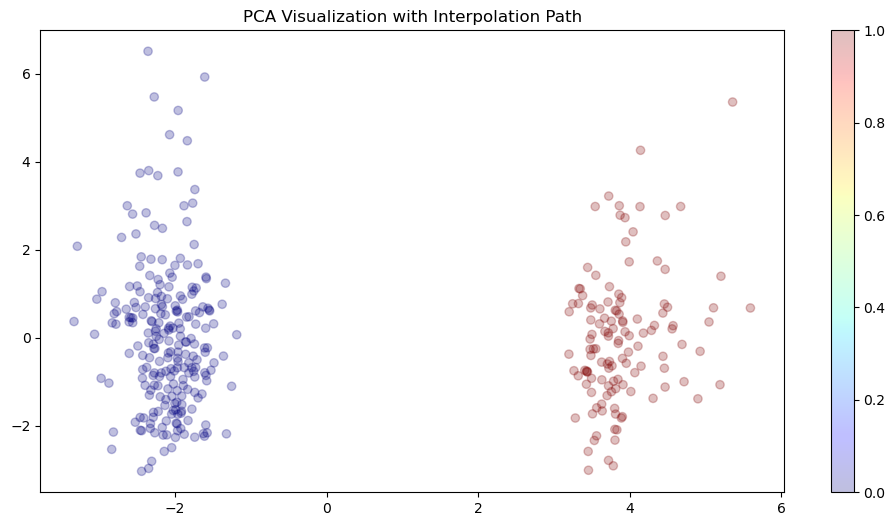

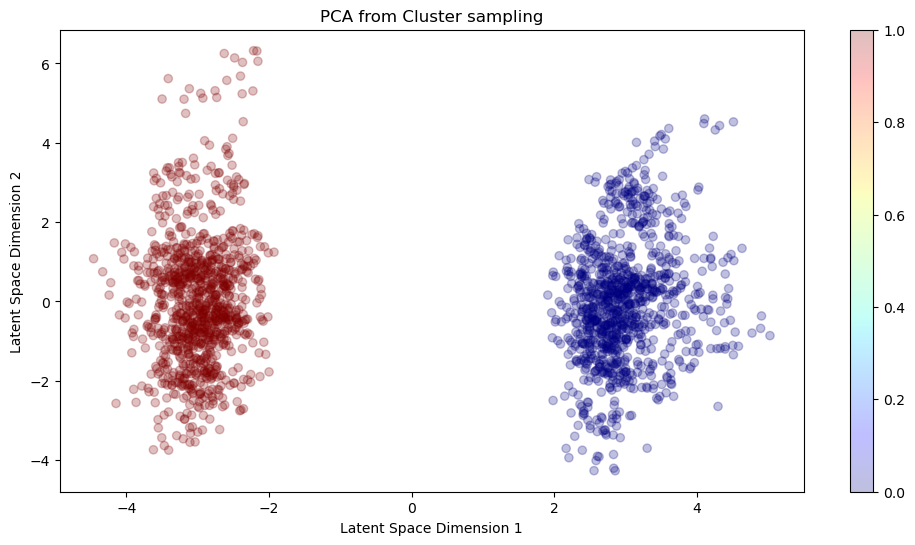

Epoch [801/1000], Recon : 0.0100, KL : 15.6743, Ortho : 468.2684, Class: 0.0080, Accuracy: 100.00%
Epoch [802/1000], Recon : 0.0098, KL : 15.3459, Ortho : 451.8325, Class: 0.0081, Accuracy: 100.00%
Epoch [803/1000], Recon : 0.0100, KL : 15.3402, Ortho : 451.9101, Class: 0.0060, Accuracy: 100.00%
Epoch [804/1000], Recon : 0.0100, KL : 15.3184, Ortho : 457.5911, Class: 0.0058, Accuracy: 100.00%
Epoch [805/1000], Recon : 0.0100, KL : 15.3425, Ortho : 463.1902, Class: 0.0068, Accuracy: 100.00%
Epoch [806/1000], Recon : 0.0102, KL : 15.1819, Ortho : 455.8347, Class: 0.0064, Accuracy: 100.00%
Epoch [807/1000], Recon : 0.0103, KL : 15.2797, Ortho : 464.8262, Class: 0.0071, Accuracy: 100.00%
Epoch [808/1000], Recon : 0.0100, KL : 15.2975, Ortho : 461.9421, Class: 0.0072, Accuracy: 100.00%
Epoch [809/1000], Recon : 0.0106, KL : 15.4451, Ortho : 464.9220, Class: 0.0073, Accuracy: 100.00%
Epoch [810/1000], Recon : 0.0104, KL : 15.5548, Ortho : 479.4106, Class: 0.0095, Accuracy: 100.00%
Epoch [811

Epoch [885/1000], Recon : 0.0101, KL : 14.8703, Ortho : 445.0966, Class: 0.0053, Accuracy: 100.00%
Epoch [886/1000], Recon : 0.0101, KL : 15.0601, Ortho : 445.8421, Class: 0.0065, Accuracy: 100.00%
Epoch [887/1000], Recon : 0.0099, KL : 15.3970, Ortho : 462.0890, Class: 0.0077, Accuracy: 100.00%
Epoch [888/1000], Recon : 0.0097, KL : 15.3550, Ortho : 457.1868, Class: 0.0072, Accuracy: 100.00%
Epoch [889/1000], Recon : 0.0100, KL : 15.4753, Ortho : 463.6208, Class: 0.0101, Accuracy: 100.00%
Epoch [890/1000], Recon : 0.0097, KL : 15.4224, Ortho : 455.7294, Class: 0.0078, Accuracy: 100.00%
Epoch [891/1000], Recon : 0.0099, KL : 15.2111, Ortho : 446.7425, Class: 0.0063, Accuracy: 100.00%
Epoch [892/1000], Recon : 0.0100, KL : 15.1644, Ortho : 451.9153, Class: 0.0051, Accuracy: 100.00%
Epoch [893/1000], Recon : 0.0103, KL : 15.1795, Ortho : 455.9104, Class: 0.0062, Accuracy: 100.00%
Epoch [894/1000], Recon : 0.0104, KL : 15.3003, Ortho : 462.9029, Class: 0.0091, Accuracy: 100.00%
Epoch [895

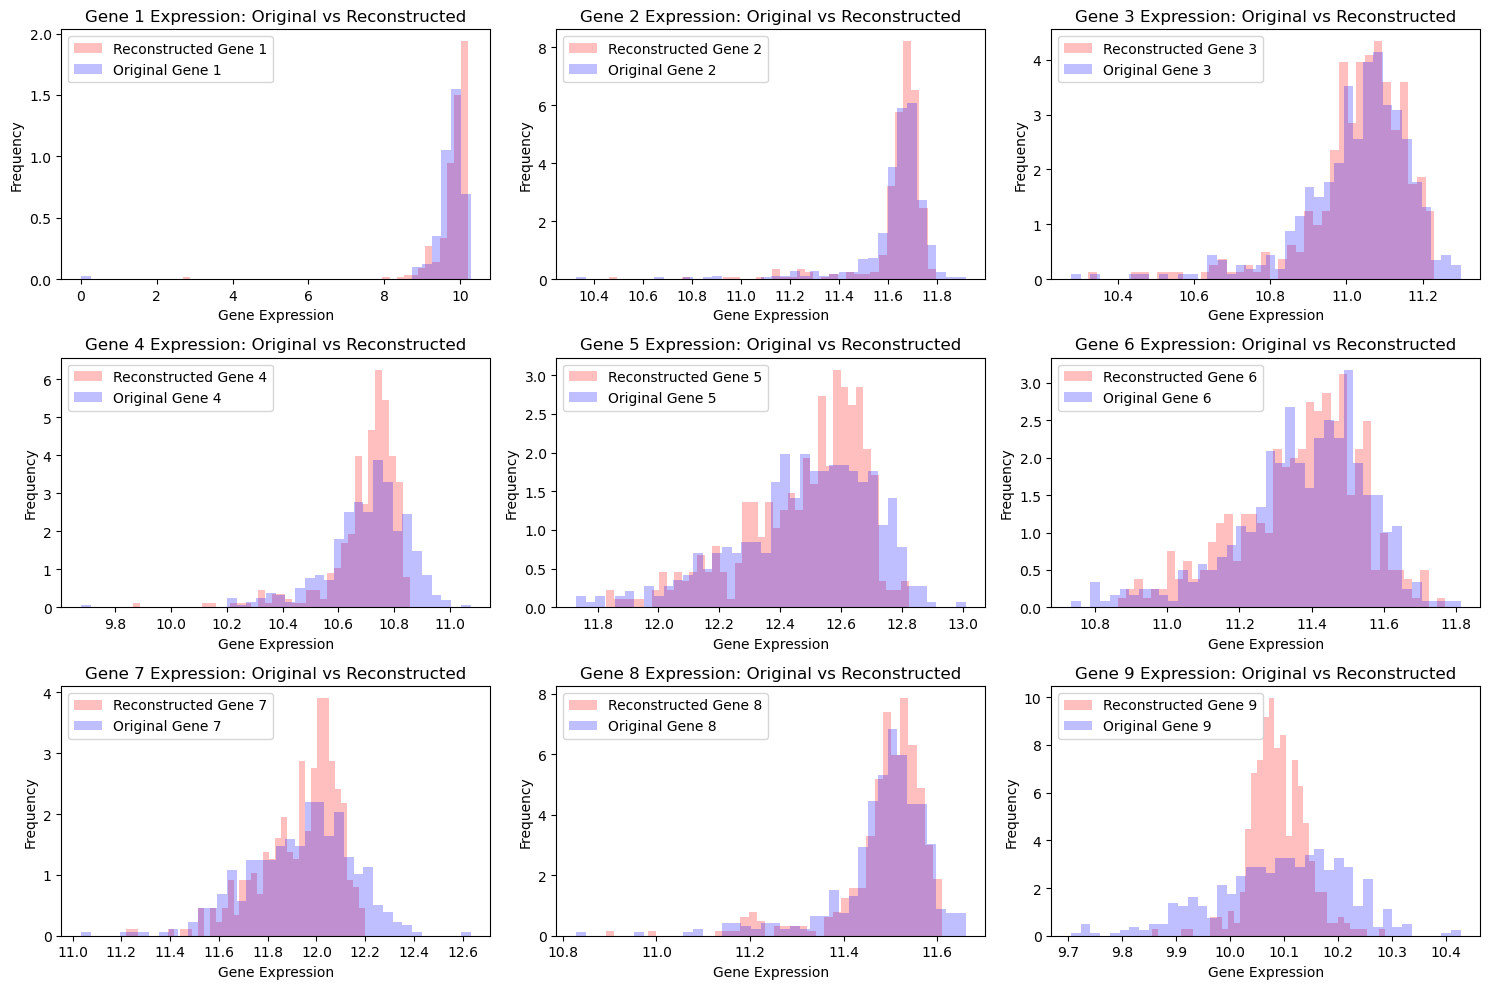

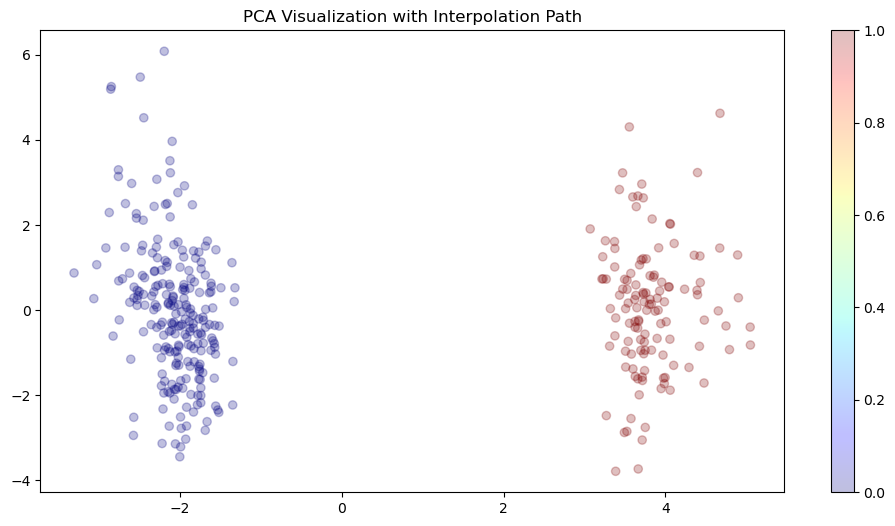

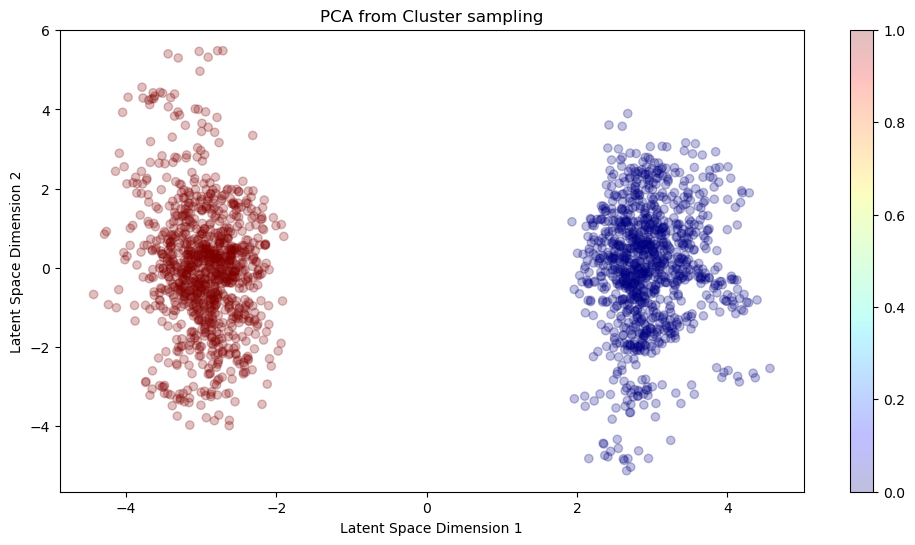

Epoch [901/1000], Recon : 0.0096, KL : 15.2696, Ortho : 454.3508, Class: 0.0065, Accuracy: 100.00%
Epoch [902/1000], Recon : 0.0096, KL : 15.1556, Ortho : 443.9475, Class: 0.0091, Accuracy: 100.00%
Epoch [903/1000], Recon : 0.0099, KL : 15.5221, Ortho : 465.0420, Class: 0.0234, Accuracy: 100.00%
Epoch [904/1000], Recon : 0.0096, KL : 17.0606, Ortho : 586.1340, Class: 0.0291, Accuracy: 100.00%
Epoch [905/1000], Recon : 0.0103, KL : 20.4361, Ortho : 906.1272, Class: 0.6982, Accuracy: 81.07%
Epoch [906/1000], Recon : 0.0110, KL : 25.0132, Ortho : 1344.9621, Class: 1.2449, Accuracy: 73.73%
Epoch [907/1000], Recon : 0.0104, KL : 18.9902, Ortho : 760.5855, Class: 0.4686, Accuracy: 81.36%
Epoch [908/1000], Recon : 0.0105, KL : 16.6027, Ortho : 534.3864, Class: 0.1960, Accuracy: 86.44%
Epoch [909/1000], Recon : 0.0100, KL : 16.0237, Ortho : 445.7948, Class: 0.1458, Accuracy: 94.07%
Epoch [910/1000], Recon : 0.0103, KL : 16.1530, Ortho : 402.4811, Class: 0.0537, Accuracy: 98.59%
Epoch [911/1000

Epoch [985/1000], Recon : 0.0099, KL : 14.9749, Ortho : 426.6571, Class: 0.0061, Accuracy: 100.00%
Epoch [986/1000], Recon : 0.0098, KL : 14.9551, Ortho : 425.3892, Class: 0.0060, Accuracy: 100.00%
Epoch [987/1000], Recon : 0.0095, KL : 14.8453, Ortho : 412.2015, Class: 0.0070, Accuracy: 100.00%
Epoch [988/1000], Recon : 0.0095, KL : 15.1044, Ortho : 436.9971, Class: 0.0057, Accuracy: 100.00%
Epoch [989/1000], Recon : 0.0099, KL : 14.8786, Ortho : 416.1290, Class: 0.0072, Accuracy: 100.00%
Epoch [990/1000], Recon : 0.0098, KL : 14.8214, Ortho : 411.6147, Class: 0.0065, Accuracy: 100.00%
Epoch [991/1000], Recon : 0.0101, KL : 15.0154, Ortho : 427.8342, Class: 0.0055, Accuracy: 100.00%
Epoch [992/1000], Recon : 0.0097, KL : 14.9116, Ortho : 416.8328, Class: 0.0063, Accuracy: 100.00%
Epoch [993/1000], Recon : 0.0098, KL : 15.0114, Ortho : 420.7844, Class: 0.0057, Accuracy: 100.00%
Epoch [994/1000], Recon : 0.0095, KL : 15.0056, Ortho : 423.8811, Class: 0.0058, Accuracy: 100.00%
Epoch [995

In [3]:


class Encoder(nn.Module):
    def __init__(self, latent_dim, gene_count, final_sequence_length, num_classes):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(gene_count * final_sequence_length + num_classes, 256)  # Additional feature for labels
        self.fc2 = nn.Linear(256, 128)
        self.fc_mean = nn.Linear(128, latent_dim)
        self.fc_log_var = nn.Linear(128, latent_dim)

    def forward(self, x, y):
        batch_size = x.size(0)  # Get the batch size
        y_expanded = y.expand(batch_size, y.size(1))  # Expand y to match batch size
        x = torch.cat([x, y_expanded], dim=1)  # Concatenate along dim=1
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        mean = self.fc_mean(x)
        log_var = self.fc_log_var(x)
        return mean, log_var


class Decoder(nn.Module):
    def __init__(self, latent_dim, gene_count):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(latent_dim, 128)
        self.fc2 = nn.Linear(128, 256)
        self.fc3 = nn.Linear(256, gene_count)
        self.sigmoid = nn.Sigmoid()

    def forward(self, z):
        x = F.relu(self.fc1(z))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        x = self.sigmoid(x)
        return x


class CVAE(nn.Module):
    def __init__(self, latent_dim, gene_count, final_sequence_length, num_classes):
        super(CVAE, self).__init__()
        self.encoder = Encoder(latent_dim, gene_count, final_sequence_length, num_classes)
        self.decoder = Decoder(latent_dim, gene_count)
        self.classifier = nn.Linear(latent_dim, num_classes)  # Classification head
        self.latent_dim = latent_dim

    def forward(self, x, y):
        mean, log_var = self.encoder(x, y)
        z = self.reparameterize(mean, log_var)
        reconstruction = self.decoder(z)
        classification_logits = self.classifier(z)  # Logits for classification
        
        return reconstruction, classification_logits, mean, log_var


    def reparameterize(self, mean, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mean + eps * std
    
    

def orthogonal_regularization(matrix):
    inner_product = torch.matmul(matrix, matrix.t())
    loss = torch.norm(inner_product - torch.eye(matrix.size(0)))
    return loss



def cvae_loss(reconstruction, x, mean, log_var, batch_size, y, classifier_loss_weight, y_pred):
    # Calculate the element-wise mean squared error for reconstruction
    mse_elementwise = F.mse_loss(reconstruction, x, reduction='none')
    reconstruction_loss = mse_elementwise.mean()

    # Calculate the KL divergence loss
    kl_divergence_loss = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp()) / batch_size

    # Classification loss (e.g., cross-entropy loss)
    classification_loss = nn.CrossEntropyLoss()(y_pred, y.argmax(dim=1))  # Modify y_pred to use appropriate logits

    orthogonal_loss = orthogonal_regularization(mean)
    # Total loss: reconstruction loss + KL divergence loss + classifier loss
    total_loss = 10000*reconstruction_loss + kl_divergence_loss + classifier_loss_weight * classification_loss 
#     total_loss = reconstruction_loss    

    return total_loss, reconstruction_loss, kl_divergence_loss, classification_loss, orthogonal_loss



# ... Define your Encoder, Decoder, and CVAE classes ...
classifier_loss_weight = 200.0
# Define your data and preprocessing
scaler = MinMaxScaler()    
normalized_X = scaler.fit_transform(X)
print("Data Min:", scaler.data_min_)
print("Data Max:", scaler.data_max_)

X_train, X_test, y_train, y_test = train_test_split(normalized_X, y, test_size=0.2)

# Print the shapes of the resulting sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
    
X_tensor = torch.tensor(X_train, dtype=torch.float32)
y_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)


# Define your data loader
batch_size = 50  # Adjust batch size as needed
gene_count = X.shape[1]  # Number of genes in your data
final_sequence_length = 1  # Since it's a single-dimensional sequence
num_classes = y.shape[1]  # Number of classes in your labels
dataset = TensorDataset(X_tensor, y_tensor)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Instantiate the CVAE model
latent_dim = 20
cvae = CVAE(latent_dim, gene_count,final_sequence_length, num_classes)

# Define the optimizer
optimizer = torch.optim.Adam(cvae.parameters(), lr=0.0001)

# ... (previous code)

# Training loop
num_epochs = 1000
save_interval = 100  # Set the interval for saving the model
model_name = "model_name_here"  # Name for saving the model
for epoch in range(num_epochs):
    total_loss = 0.0
    total_reconstruction_loss = 0.0
    total_kl_loss = 0.0
    total_classification_loss = 0.0  # Initialize classification loss
    total_ortho_loss = 0.0
    total_samples = 0
    correct_predictions = 0
    # Inside your training loop
    for batch_X, batch_y in data_loader:
        optimizer.zero_grad()
        # Reshape batch_y to have shape (batch_size, num_classes)
        batch_y_reshaped = batch_y.view(batch_y.size(0), -1) 
        # Pass through the CVAE
        reconstruction, classification_logits, mean, log_var = cvae(batch_X, batch_y_reshaped)
        # Calculate the VAE loss
        loss, lossR, lossKL, lossClassifier, lossOrtho = cvae_loss(reconstruction, batch_X, mean, log_var, batch_size, batch_y_reshaped, classifier_loss_weight, classification_logits)
        loss.backward()
        optimizer.step()
        total_reconstruction_loss += lossR.item()
        total_kl_loss += lossKL.item()
        total_classification_loss += lossClassifier.item()
        total_ortho_loss += lossOrtho.item()
        probabilities = F.softmax(classification_logits, dim=1)
        predicted_classes = torch.argmax(probabilities, dim=1)
#         print(classification_logits)
        correct_predictions += (predicted_classes == batch_y.argmax(dim=1)).sum().item()
        total_samples += batch_X.size(0)
        
    if epoch % save_interval == 0:
        torch.save(cvae.state_dict(), f"{model_name}.pt")
    if epoch%100 == 0:
         plot_reconstructions()
               
                
        
         l0, l1 = 0,1
         ylabels = np.zeros(len(y))
         for i in range(len(y)):
             ylabels[i] = y[i].argmax()
         X0 = X[ylabels == l0]
         X1 = X[ylabels == l1]
         num_genes = X.shape[1]
         num_samples = 1*10**3
         sigma_factor = 10.

            # samples latent space points around the label0 and 1 centroids and reconstructs (decodes) each point with cvae
         cX0_reconstructed, X1_reconstructed = sample_from_ball_01(num_samples,l0,l1)
        

    average_reconstruction_loss = total_reconstruction_loss / len(data_loader)
    average_kl_loss = total_kl_loss / len(data_loader)
    average_classification_loss = total_classification_loss / len(data_loader)
    accuracy = correct_predictions / total_samples * 100.0
    average_ortho_loss = total_ortho_loss/ len(data_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}], "
          f"Recon : {average_reconstruction_loss:.4f}, "
          f"KL : {average_kl_loss:.4f}, "
          f"Ortho : {average_ortho_loss:.4f}, "
          f"Class: {average_classification_loss:.4f}, Accuracy: {accuracy:.2f}%")

print("Training complete.")


dataset_test = TensorDataset(X_test_tensor, y_test_tensor)
data_loader_test = DataLoader(dataset_test, batch_size=1, shuffle=False)
cvae.eval()

num_epochs = 1
for epoch in range(num_epochs):

    total_samples = 0
    correct_predictions = 0
    # Inside your training loop
    for batch_X, batch_y in data_loader_test:
        
        batch_y_reshaped = batch_y.view(batch_y.size(0), -1) 
#         print(batch_y_reshaped)
        batch_y_reshaped = torch.tensor([[0., 0.]], dtype=torch.float32)
        
        # Pass through the CVAE
        reconstruction, classification_logits, mean, log_var = cvae(batch_X, batch_y_reshaped)        
        probabilities = F.softmax(classification_logits, dim=1)
        predicted_classes = torch.argmax(probabilities, dim=1)
#         print(batch_y, probabilities)
        correct_predictions += (predicted_classes == batch_y.argmax(dim=1)).sum().item()
        total_samples += batch_X.size(0)

    
    accuracy = correct_predictions / total_samples * 100.0

    print(f" Testing Classification Accuracy: {accuracy:.2f}%")



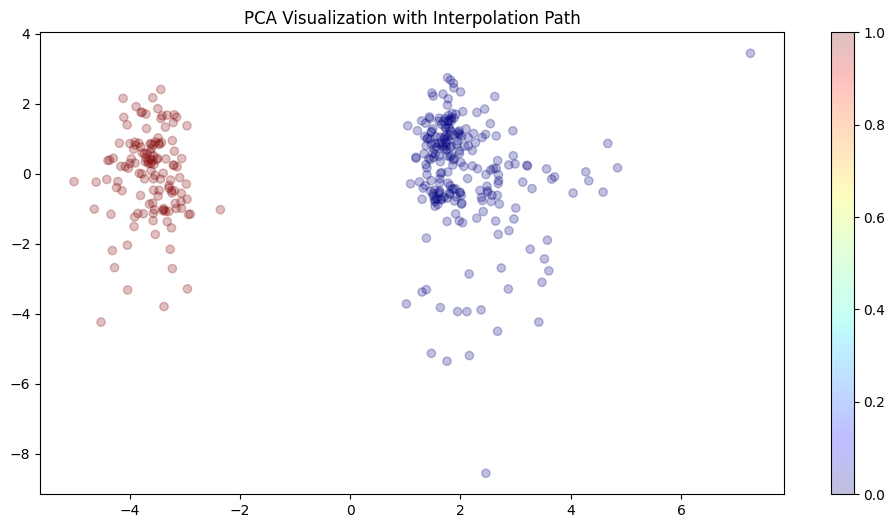

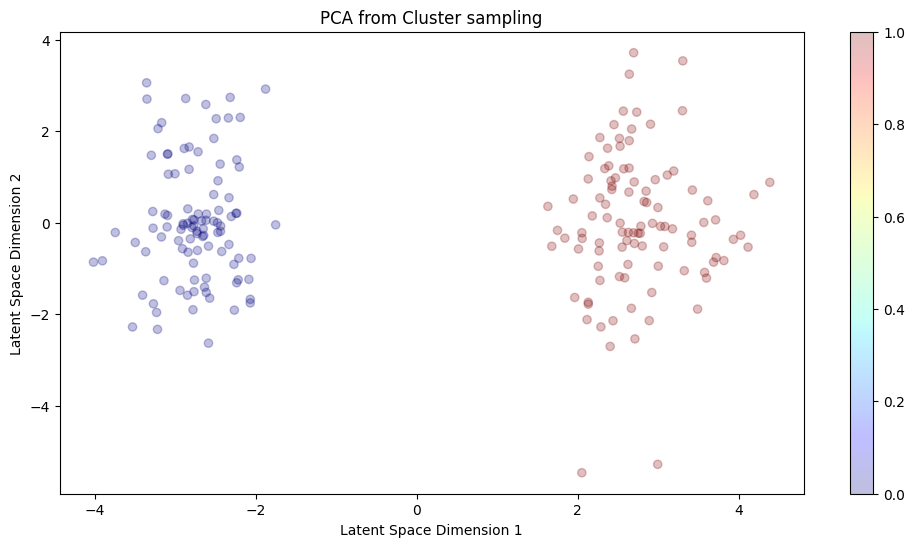

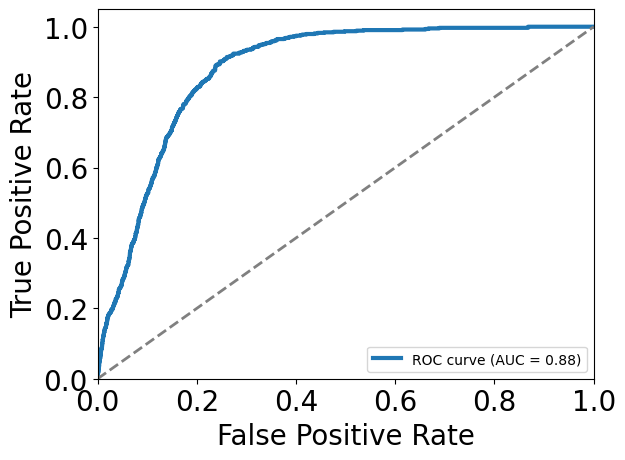

In [6]:
def get_selected_genes(select_ngenes, l0, l1):
    X0 = X[ylabels == l0]
    X1 = X[ylabels == l1]
    num_genes = X.shape[1]
    num_samples = 1*10**2
    sigma_factor = 1
    # samples latent space points around the label0 and 1 centroids and reconstructs (decodes) each point with cvae
    X0_reconstructed, X1_reconstructed = sample_from_ball_01(num_samples, l0, l1)

    # Perform t-test for each gene
    p_values, p_values_R = [], []
    for gene_idx in range(num_genes):
        t_stat, p_value = stats.ttest_ind(X0[:, gene_idx], X1[:, gene_idx])
        p_values.append(p_value)
        t_stat, p_value = stats.ttest_ind(X0_reconstructed[:, gene_idx], X1_reconstructed[:, gene_idx])
        p_values_R.append(p_value)

    # Correct for multiple comparisons (e.g., Bonferroni correction)
    p_values, p_values_R = np.array(p_values) , np.array(p_values_R)   # Bonferroni correction
    # Sort significant genes by p-value
    ind_genes_R =  np.flip(np.argsort(-np.log10(p_values_R))) #sorts from lowest p value to heighest 

    significance_thresholds = [  5*10**(-2)]

    plt.figure()
    for significance_threshold in significance_thresholds:

        ttest_results = np.zeros(len(p_values)).astype(int)
        for i in range(len(p_values)):
            if p_values[i] < significance_threshold:
                ttest_results[i] = 1

        ttest_results = ttest_results[ind_genes_R]
        vae_scores = -np.log10(p_values_R)[ind_genes_R]
        
        fpr, tpr, thresholds = roc_curve(ttest_results, vae_scores)
        # return p_values, fpr, tpr, thresholds 
        roc_auc = roc_auc_score(ttest_results, vae_scores)

        plt.plot(fpr, tpr, lw=3, label=f'ROC curve (AUC = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xticks(fontsize=20)
        plt.yticks(fontsize=20)
        plt.xlabel('False Positive Rate', fontsize = 20)
        plt.ylabel('True Positive Rate', fontsize = 20)
        plt.legend(loc='lower right')
    
    plt.show()
    
get_selected_genes(200, l0, l1)

# select_ngenes = 200
# glist = []
# for i in range(1):
#     glist.append(get_selected_genes(select_ngenes, l0, l1))
    

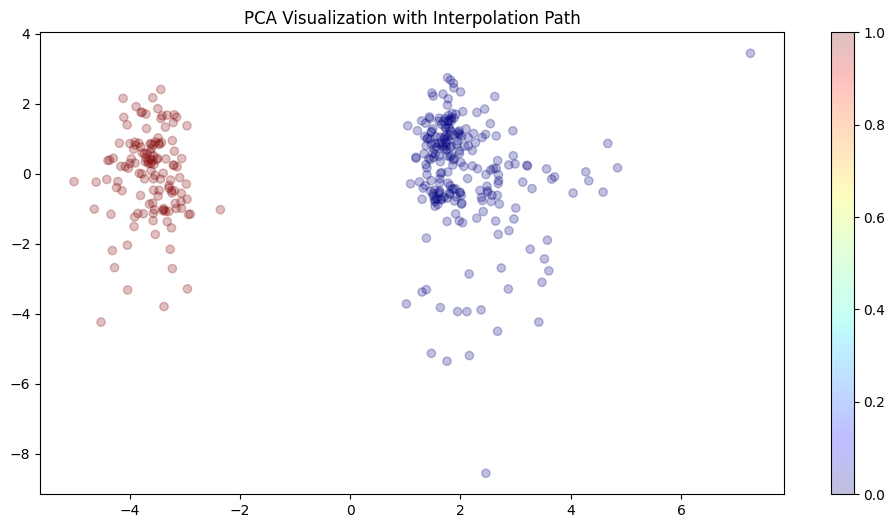

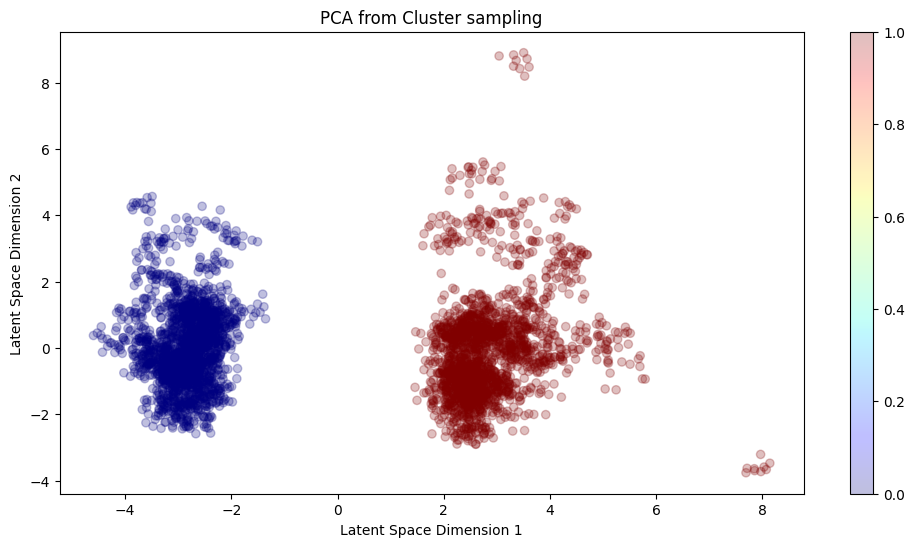

In [7]:


def get_E01(X, ylabels, num_components=100, num_samples=2*10**3, sigma_factor=1., c_thresh=0.5, top_n=7):

    normalized_X = scaler.fit_transform(X)
    # Sample latent space points around the label 0 and 1 centroids and reconstruct them with CVAE
    X0_reconstructed, X1_reconstructed = sample_from_ball_01(num_samples, l0, l1)
    X0_reconstructed = scaler.inverse_transform(X0_reconstructed)
    X1_reconstructed = scaler.inverse_transform(X1_reconstructed)
    
    Xr = np.concatenate((X0_reconstructed, X1_reconstructed))
    U, S, Vt = np.linalg.svd(Xr.T, full_matrices=True)


    E01 = Xr@U
            

    one_hot_labels = np.eye(E01.shape[0])
#     # Concatenate the one-hot labels with the original E01 matrix
    E01_with_labels = np.concatenate((one_hot_labels, E01), axis=1)

        
    return E01, E01_with_labels, U,Vt, Xr, X0_reconstructed, X1_reconstructed

# Usage example:
E01_full, E01_with_labels, U,Vt, Xr,X0r, X1r = get_E01(X, ylabels)


max_components = 200
topU = U[:,:max_components]
E01 = Xr@topU

# dX = np.zeros(np.shape(Xr))
# for i in range(len(dX)):
#     dX[i] = Xr[i] - np.mean(Xr[i])
# E01test = dX@topU

Accuracy: 1.0
Confusion Matrix:
 [[378   0]
 [  0 422]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       378
           1       1.00      1.00      1.00       422

    accuracy                           1.00       800
   macro avg       1.00      1.00      1.00       800
weighted avg       1.00      1.00      1.00       800

Log Probabilities for Positive Class:
 [-2.83572954 -0.05125546 -2.84769277 -0.09400892 -0.09384099 -2.75932283
 -2.7834094  -0.09443813 -2.49559227 -0.07664273]


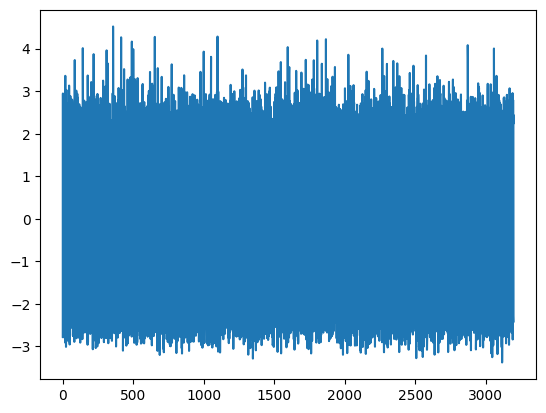

In [8]:

# Assuming X is your gene expression matrix and y_class is the one-hot encoded vector
# Convert one-hot encoded labels to binary labels

y_class = []
for i in range(int(len(E01)/2)):
    y_class.append([0.,1.])
for i in range(int(len(E01)/2)):
    y_class.append([1.,0.])
y_class  = np.asarray(y_class)

# Split the data into training and testing sets
normalized_X = scaler.fit_transform(E01)
# X_train, X_test, y_train, y_test = train_test_split(normalized_X, np.argmax(y_class, axis=1), test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(normalized_X, np.argmax(y_class, axis=1), test_size=0.2, random_state=42)
# X_train, X_test, y_train, y_test = train_test_split(X, np.argmax(y, axis=1), test_size=0.2, random_state=42)
# X_train, X_test, y_train, y_test = normalized_X,normalized_X, np.argmax(y_class, axis=1) ,np.argmax(y_class, axis=1) 
# Initialize the logistic regression model
model = LogisticRegression(max_iter=10000)

# Train the model on the training data
model.fit(X_train, y_train)

# Make predictions on the testing data
y_pred = model.predict(X_test)
# y_pred = model.predict(X_train)

# Get predicted probabilities for the positive class
log_probabilities = model.predict_log_proba(X_train)[:, 1]

# Other evaluations
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Print the results
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", classification_rep)

# Print the first few predicted log probabilities
print("Log Probabilities for Positive Class:\n", log_probabilities[:10])


# Get log-odds for positive and negative classes
log_odds_positive = model.predict_log_proba(X_train)[:, 1]
log_odds_negative = model.predict_log_proba(X_train)[:, 0]

# Calculate the odds ratio
odds_ratio = log_odds_positive - log_odds_negative

# Print the first few odds ratios
plt.plot(odds_ratio)
plt.show()




1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000
13000
14000
15000
16000
17000
18000
19000
20000
21000
22000
23000
24000
25000
26000
27000
28000
29000
30000
31000
32000
33000
34000
35000
36000
37000
38000
39000
40000
41000
42000
43000
44000
45000
46000
47000
48000
49000
50000
51000
52000
53000
54000
55000
56000
57000
58000
59000
60000
61000
62000
63000
64000
65000
66000
67000
68000
69000
70000
71000
72000
73000
74000
75000
76000
77000
78000
79000
80000
81000
82000
83000
84000
85000
86000
87000
88000
89000
90000
91000
92000
93000
94000
95000
96000
97000
98000
99000
100000
Posterior Inclusion Probabilities: [7.4434e-01 1.0000e+00 2.9130e-02 9.9370e-01 9.9389e-01 7.5380e-02
 7.4438e-01 1.0000e+00 1.0000e+00 1.0000e+00 2.3588e-01 1.0000e+00
 2.8650e-02 1.0000e+00 1.0000e+00 1.4435e-01 1.0000e+00 7.3301e-01
 3.8813e-01 1.0000e+00 2.8210e-02 3.3613e-01 3.2000e-03 7.4000e-03
 3.2000e-04 4.4650e-02 5.7068e-01 1.0000e+00 6.8624e-01 6.2338e-01
 2.4310e-02 2.5800e-03 1.8189e-01 3.50

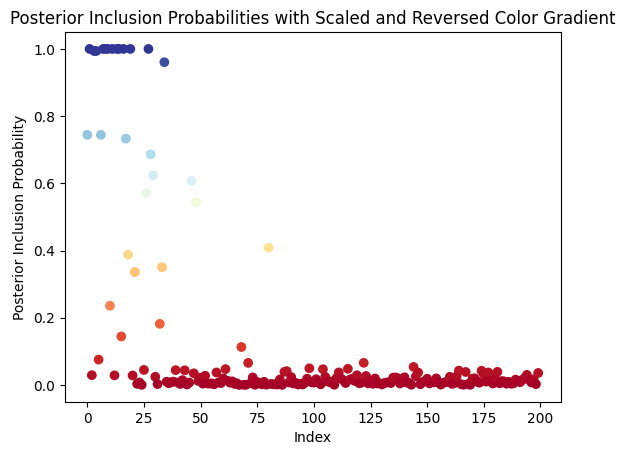

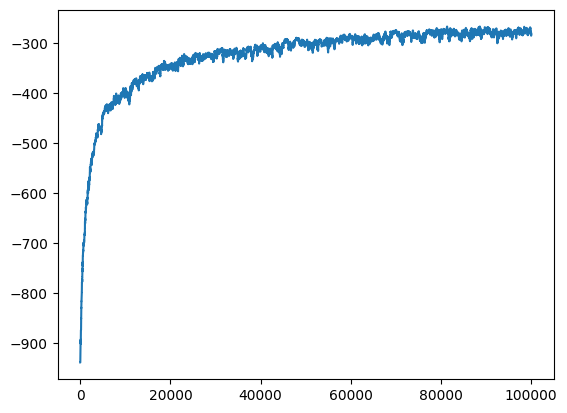

In [9]:
import numpy as np
import scipy.stats as stats
from numba import jit

# Assuming X_train, odds_ratio are defined
# Define simulated data
# np.random.seed(42)
negenes = len(X_train[0])

sig2 = 4

pk = np.zeros(negenes)
m = negenes
for k in range(len(pk)):
    pk[k] = (1/m)**k*(1-1/m)**(m-k)

z_values, R = (X_train.T @ odds_ratio) / (negenes * sig2) ** 0.5, (X_train.T @ X_train) / negenes
z_values = np.array(z_values, dtype=np.float32)
R = np.array(R, dtype=np.float32)
R = R.astype(np.float64)

# Vectorized log-likelihood function
@jit(nopython=True)
def log_likelihood(gamma, s, R, z_values):
    gamma = gamma.astype(np.float64)  # Cast gamma to float64
    Sigma = np.diag(gamma * s**2.*negenes)
    cov_matrix = R + R @ Sigma @ R
    prior_k = pk[len(np.nonzero(gamma)[0])]
    
    # Convert z_values to float64
    z_values = z_values.astype(np.float64)
    
    # Perform the dot product with arrays of the same dtype
    dot_product = np.dot(z_values, np.linalg.solve(cov_matrix, z_values))
    return np.log(prior_k) - 0.5 * dot_product

@jit(nopython=True)
def metropolis_mcmc(num_samples, burn_in, proposal_std):
    # Initialize parameters
    gamma = np.random.randint(0, 2, size=negenes)
    s = 0.05
    pip = np.zeros(negenes, dtype=np.int64)
#     samples = np.zeros((num_samples, negenes), dtype=np.int64)
    loss = np.zeros(num_samples)
    for _ in range(num_samples + burn_in):
        index_to_flip = np.random.randint(0, negenes)
        gamma_proposed = gamma.copy()
        gamma_proposed[index_to_flip] = 1 - gamma_proposed[index_to_flip]
        s_proposed = s + np.random.normal(0.0, proposal_std)
#         s_proposed = s 

        ll_new, ll_old = log_likelihood(gamma_proposed, s_proposed, R, z_values),log_likelihood(gamma, s, R, z_values)
        # Calculate acceptance ratio
        log_ratio = ll_new - ll_old
    
        if np.log(np.random.rand()) < log_ratio:
            gamma, s = gamma_proposed, s_proposed
            

        # Save samples after burn-in
        if _ >= burn_in:
            loss[_ - burn_in] = ll_old
#             samples[_ - burn_in, :] = gamma.copy()
            pip = pip + gamma.copy()
            if _ % 1000 == 0:
                print(_)

    return loss, pip/num_samples



# Run Metropolis MCMC
num_samples = 100000
burn_in = 1000
# num_samples = 100
# burn_in = 100
proposal_std = 0.001
loss, posterior_inclusion_probabilities = metropolis_mcmc(num_samples, burn_in, proposal_std)

# # Calculate MLE of gamma
# mle_gamma = np.mean(samples, axis=0)

# Calculate posterior inclusion probabilities
# posterior_inclusion_probabilities = np.mean(samples, axis=0)

# Print results
# print("MLE of gamma:", mle_gamma)
print("Posterior Inclusion Probabilities:", posterior_inclusion_probabilities)

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

# Assuming posterior_inclusion_probabilities is defined

# Normalize the inclusion probabilities to the range [0, 1]
norm = Normalize(vmin=0, vmax=1)
colors = plt.cm.RdYlBu(norm(posterior_inclusion_probabilities))

# Plot the points with the reversed colors
plt.scatter(range(len(posterior_inclusion_probabilities)), posterior_inclusion_probabilities, c=colors, marker='o')

# Add labels and title
plt.xlabel('Index')
plt.ylabel('Posterior Inclusion Probability')
plt.title('Posterior Inclusion Probabilities with Scaled and Reversed Color Gradient')

# Show the colorbar to indicate the mapping from values to colors
# cbar = plt.colorbar()
# cbar.set_label('Posterior Inclusion Probability')

# Show the plot
plt.show()

plt.plot(loss)
plt.show()

In [10]:
sorted_egene_indices = np.argsort(posterior_inclusion_probabilities)
# np.save('sorted_egene_indices_asthma',sorted_egene_indices)
top_egene_indices = np.flip(np.argsort(posterior_inclusion_probabilities)[-50:])

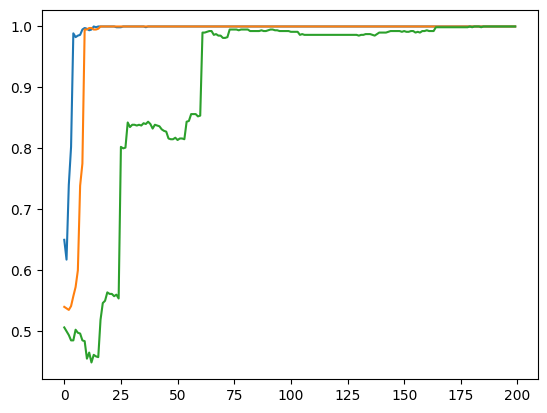

In [11]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Assuming X is your gene expression matrix and y_class is the one-hot encoded vector
# Convert one-hot encoded labels to binary labels

y_class = []
for i in range(int(len(E01)/2)):
    y_class.append([0.,1.])
for i in range(int(len(E01)/2)):
    y_class.append([1.,0.])
y_class  = np.asarray(y_class)

max_acc = 0.
accuracy = []
for i in range(200):
    
        
        
# Split the data into training and testing sets
    eval_inds = np.flip(sorted_egene_indices)[:i+1]
    scaler = MinMaxScaler() 
    normalized_X = scaler.fit_transform(E01[:,eval_inds])
    X_train, X_test, y_train, y_test = train_test_split(normalized_X, np.argmax(y_class, axis=1), test_size=0.2, random_state=42)
   
    model = LogisticRegression(max_iter=10000)

        # Train the model on the training data
    model.fit(X_train, y_train)

        # Make predictions on the testing data
    y_pred = model.predict(X_test)
     
    accuracy.append(accuracy_score(y_test, y_pred)) 
    
top50_accuracy = []
for i in range(200):
    
        
        
# Split the data into training and testing sets
    eval_inds = np.arange(i+1)
    scaler = MinMaxScaler() 
    normalized_X = scaler.fit_transform(E01[:,eval_inds])
    X_train, X_test, y_train, y_test = train_test_split(normalized_X, np.argmax(y_class, axis=1), test_size=0.2, random_state=42)
 
        # Initialize the logistic regression model
    model = LogisticRegression(max_iter=10000)

        # Train the model on the training data
    model.fit(X_train, y_train)

        # Make predictions on the testing data
    y_pred = model.predict(X_test)
     
    top50_accuracy.append(accuracy_score(y_test, y_pred))
    
rand_accuracy = []
arr = np.arange(200)
np.random.shuffle(arr)
for i in range(200):
    
        
        
# Split the data into training and testing sets
    eval_inds = arr[:i+1]
    scaler = MinMaxScaler() 
    normalized_X = scaler.fit_transform(E01[:,eval_inds])
    X_train, X_test, y_train, y_test = train_test_split(normalized_X, np.argmax(y_class, axis=1), test_size=0.2, random_state=42)
  
    model = LogisticRegression(max_iter=10000)

        # Train the model on the training data
    model.fit(X_train, y_train)

        # Make predictions on the testing data
    y_pred = model.predict(X_test)
     
    rand_accuracy.append(accuracy_score(y_test, y_pred))
  

plt.plot(accuracy)
plt.plot(top50_accuracy)
plt.plot(rand_accuracy)
plt.show()



In [12]:
Delta_gctx = parse.parse('gene_perturbations_for_ben.gctx')
Delta_gctx.data_df


# Specify the path to the gzipped text file
file_path = 'mart_export.txt-2.gz'

# Open the gzipped file and read it into a DataFrame
with gzip.open(file_path, 'rt') as file:
    df_genenames = pd.read_csv(file, sep='\t')

# Display the DataFrame
print(df_genenames)

/opt/homebrew/Caskroom/miniconda/base/envs/my_env/lib/python3.11/site-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))
/opt/homebrew/Caskroom/miniconda/base/envs/my_env/lib/python3.11/site-packages/cmapPy/pandasGEXpress/parse_gctx.py:275: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  meta_df = meta_df.apply(lambda x: pd.to_numeric(x, errors="ignore"))


       Gene stable ID,Gene stable ID version,Transcript stable ID,Transcript stable ID version,Gene name,Gene Synonym
0       ENSG00000276191,ENSG00000276191.4,ENST00000632...                                                            
1       ENSG00000276191,ENSG00000276191.4,ENST00000617...                                                            
2       ENSG00000276191,ENSG00000276191.4,ENST00000616...                                                            
3       ENSG00000276191,ENSG00000276191.4,ENST00000633...                                                            
4       ENSG00000276191,ENSG00000276191.4,ENST00000616...                                                            
...                                                   ...                                                            
541863  ENSG00000288396,ENSG00000288396.1,ENST00000672...                                                            
541864  ENSG00000285065,ENSG00000285065.1,ENST00000643..

In [13]:
matching_indices = np.load('matching_indices_asthma_rnaseq.npy')

In [14]:
disease_ind, gene_pert_ind = matching_indices[:,0], matching_indices[:,1]

In [15]:
estar = U.T[top_egene_indices][:,disease_ind]

In [16]:
A = Delta_gctx.data_df.iloc[:,gene_pert_ind].to_numpy()
Delta_cc = np.mean(X1r[:,disease_ind] - X0r[:,disease_ind], axis = 0)

In [17]:
import numpy as np
from scipy.optimize import minimize

# Define the objective function L(u)
def objective_function(u, A, D, lambda_val):
    term1 = sum((D - A@u)**2.)**.5 + lambda_val*np.sum(u)
    return term1 

# Define the constraint that u elements should be between 0 and 1
constraint = {'type': 'ineq', 'fun': lambda u: np.array([1 - elem for elem in u] + [elem for elem in u])}

# Example data
D = estar@Delta_cc   # Replace this with your actual D vector
lambda_val = .1          # Replace this with your actual lambda value
EA = estar@A.T
# Initial guess for u
initial_u = np.random.rand(len(A))

# Solve the optimization problem
# result = minimize(objective_function, initial_u, args=(A.T, D, lambda_val), constraints=constraint)
result = minimize(objective_function, initial_u, args=(EA, D, lambda_val), constraints=constraint)

# Extract the optimal u
optimal_u = result.x


print("Optimal u:", optimal_u)
print("Objective function value:", result.fun)

print(1-np.linalg.norm(estar@(Delta_cc-A.T@optimal_u),2)/np.linalg.norm(estar@Delta_cc,2))

sorted_optimal_u = np.argsort(optimal_u)[::-1]
Delta_gctx.row_metadata_df.iloc[sorted_optimal_u[:60]]


Optimal u: [2.69610809e-04 4.24221167e-03 6.88063600e-05 ... 2.24323939e-05
 1.25263216e-05 2.14769617e-04]
Objective function value: 0.9093842659442006
0.9937882209820358


rhd,bioproject,fin_cell_line,fin_cell_type,fin_genotype,fin_treatment,init_cell_line,init_cell_type,init_genotype,init_treatment,sense
rid,,,,,,,,,,
44833,PRJNA395325,KYSE-70,esophagus;squamous_cell_carcinoma,LINC01672,kd,KYSE-70,esophagus;squamous_cell_carcinoma,NONE,nc-kd,kd
44038,PRJNA320835,22Rv1,prostate;carcinoma,C17orf49,nc-drug; kd,22Rv1,prostate;carcinoma,NONE,nc-drug; nc-kd,kd
44339,PRJNA352410,MM.1s,plasma_cell_myeloma,CD86,kd,MM.1s,plasma_cell_myeloma,NONE,nc-kd,kd
44136,PRJNA339568,Hs578T,breast;ductal_carcinoma,ADAR; ADARB1,kd; kd,Hs578T,breast;ductal_carcinoma,ADAR,oe,kd
44494,PRJNA376585,MCF7,breast;carcinoma,YBX1,oe,MCF7,breast;carcinoma,NONE,nc,oe
43458,PRJEB28808,U2OS,osteosarcoma,IKBKB,actinomycin D; irradiated; kd,U2OS,osteosarcoma,NONE,actinomycin D; irradiated; nc-kd,kd
43578,PRJNA231463,NB-4,acute_myeloid_leukemia,TFEB,ATRA; kd,NB-4,acute_myeloid_leukemia,NONE,ATRA; nc-kd,kd
44178,PRJNA339568,SLR25,clear_cell_renal_cell_carcinoma,ADAR,oe,SLR25,clear_cell_renal_cell_carcinoma,NONE,nc-oe,oe
43725,PRJNA261439,HeLa,endometrium;adenocarcinoma,VIRMA,kd,HeLa,endometrium;adenocarcinoma,NONE,nc,kd
